In [83]:
import sys
import os
sys.path.append(os.path.dirname(os.getcwd()))
from shared.collect_data import DataCollector
from shared.clean_data import DataCleaning
import ta
import matplotlib.pyplot as plt


# Data Collection

In [35]:
data_collector = DataCollector(
    symbol = "BTC/USDT", 
    timeframe = "5m", 
    days = 365,
    limit = 1000
)
df = data_collector.collect_data()

In [36]:
df.head()

,timestamp,open,high,low,close,volume
0,2024-06-04 01:25:00,68998.02,69020.00,68998.01,69012.99,13.62485
1,2024-06-04 01:30:00,69012.98,69180.00,69001.24,69138.28,59.24947
2,2024-06-04 01:35:00,69138.29,69149.00,69077.32,69079.10,28.97539
3,2024-06-04 01:40:00,69079.10,69097.21,69074.00,69074.00,26.80362
4,2024-06-04 01:45:00,69074.01,69100.00,69051.23,69099.99,52.87717


In [37]:
df.describe()

,timestamp,open,high,low,close,volume
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000
mean,2024-12-03 13:25:00.000000256,81042.380906,81118.043057,80965.442790,81042.730097,98.998987
min,2024-06-04 01:25:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100
25%,2024-09-03 07:25:00,64098.610000,64136.660000,64050.000000,64098.600000,32.183960
50%,2024-12-03 13:25:00,83820.170000,83900.000000,83733.720000,83820.620000,58.659040
75%,2025-03-04 19:25:00,96572.010000,96638.740000,96500.000000,96572.010000,112.422820
max,2025-06-04 01:25:00,111924.070000,111980.000000,111812.420000,111924.080000,5471.439430
std,NaN,16943.176365,16957.550776,16928.193985,16943.307456,139.372714


# Clean Data

In [38]:
clean_data = DataCleaning(
    df=df,
)

df = clean_data.clean_data()

In [39]:
df.describe()

,timestamp,open,high,low,close,volume
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000
mean,2024-12-03 13:25:00.000000256,81042.380906,81118.043057,80965.442790,81042.730097,71.045169
min,2024-06-04 01:25:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100
25%,2024-09-03 07:25:00,64098.610000,64136.660000,64050.000000,64098.600000,32.183960
50%,2024-12-03 13:25:00,83820.170000,83900.000000,83733.720000,83820.620000,58.659040
75%,2025-03-04 19:25:00,96572.010000,96638.740000,96500.000000,96572.010000,98.998987
max,2025-06-04 01:25:00,111924.070000,111980.000000,111812.420000,111924.080000,232.755460
std,NaN,16943.176365,16957.550776,16928.193985,16943.307456,48.977512


# Technical Indicators

### Momentum Indicators

#### <font color="#5283fe">Awesome Oscillator (AO)</font>
###### The Awesome Oscillator is an indicator used to measure market momentum. AO calculates the difference of a 34 Period and 5 Period Simple Moving Averages. The Simple Moving Averages that are used are not calculated using closing price but rather each bar’s midpoints. AO is generally used to affirm trends or to anticipate possible reversals.

In [40]:
df["AO"] = ta.momentum.AwesomeOscillatorIndicator(
    high=df["high"],
    low=df["low"],
    window1=5,
    window2=34
).awesome_oscillator()

df.describe()

,timestamp,open,high,low,close,volume,AO
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000
mean,2024-12-03 13:25:00.000000256,81042.380906,81118.043057,80965.442790,81042.730097,71.045169,5.001187
min,2024-06-04 01:25:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088
25%,2024-09-03 07:25:00,64098.610000,64136.660000,64050.000000,64098.600000,32.183960,-138.607816
50%,2024-12-03 13:25:00,83820.170000,83900.000000,83733.720000,83820.620000,58.659040,9.213662
75%,2025-03-04 19:25:00,96572.010000,96638.740000,96500.000000,96572.010000,98.998987,155.085919
max,2025-06-04 01:25:00,111924.070000,111980.000000,111812.420000,111924.080000,232.755460,4895.497941
std,NaN,16943.176365,16957.550776,16928.193985,16943.307456,48.977512,363.407385


#### <font color="#5283fe">Kaufman’s Adaptive Moving Average (KAMA)</font>
###### Moving average designed to account for market noise or volatility. KAMA will closely follow prices when the price swings are relatively small and the noise is low. KAMA will adjust when the price swings widen and follow prices from a greater distance. This trend-following indicator can be used to identify the overall trend, time turning points and filter price movements.

In [41]:
df["KAMA"] = ta.momentum.KAMAIndicator(close=df['close']).kama()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000
mean,2024-12-03 13:25:00.000000256,81042.380906,81118.043057,80965.442790,81042.730097,71.045169,5.001187,81038.971722
min,2024-06-04 01:25:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750
25%,2024-09-03 07:25:00,64098.610000,64136.660000,64050.000000,64098.600000,32.183960,-138.607816,64113.946546
50%,2024-12-03 13:25:00,83820.170000,83900.000000,83733.720000,83820.620000,58.659040,9.213662,83834.174504
75%,2025-03-04 19:25:00,96572.010000,96638.740000,96500.000000,96572.010000,98.998987,155.085919,96577.352006
max,2025-06-04 01:25:00,111924.070000,111980.000000,111812.420000,111924.080000,232.755460,4895.497941,111640.246496
std,NaN,16943.176365,16957.550776,16928.193985,16943.307456,48.977512,363.407385,16943.646188


#### <font color="#5283fe">Percentage Price Oscillator (PPO)</font>
###### is a momentum oscillator that measures the difference between two moving averages as a percentage of the larger moving average.

In [42]:
ppo = ta.momentum.PercentagePriceOscillator(
    close=df['close'],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["PPO"] = ppo.ppo()

df["PPO_HIST"] = ppo.ppo_hist()

df["PPO_SIGNAL"] = ppo.ppo_signal()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,105088.000000
mean,2024-12-03 13:25:00.000000256,81042.380906,81118.043057,80965.442790,81042.730097,71.045169,5.001187,81038.971722,0.002549,-0.000002,0.002548
min,2024-06-04 01:25:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-0.622071,-1.608772
25%,2024-09-03 07:25:00,64098.610000,64136.660000,64050.000000,64098.600000,32.183960,-138.607816,64113.946546,-0.068516,-0.023339,-0.064762
50%,2024-12-03 13:25:00,83820.170000,83900.000000,83733.720000,83820.620000,58.659040,9.213662,83834.174504,0.005139,-0.000412,0.005039
75%,2025-03-04 19:25:00,96572.010000,96638.740000,96500.000000,96572.010000,98.998987,155.085919,96577.352006,0.078722,0.023329,0.074713
max,2025-06-04 01:25:00,111924.070000,111980.000000,111812.420000,111924.080000,232.755460,4895.497941,111640.246496,1.823188,0.678299,1.701378
std,NaN,16943.176365,16957.550776,16928.193985,16943.307456,48.977512,363.407385,16943.646188,0.176040,0.052628,0.165923


#### <font color="#5283fe">Percentage Volume Oscillator (PVO)</font>
###### is a momentum oscillator for volume. The PVO measures the difference between two volume-based moving averages as a percentage of the larger moving average.

In [43]:
pvo = ta.momentum.PercentageVolumeOscillator(
    volume =df['volume'],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["PVO"] = pvo.pvo()

df["PVO_HIST"] = pvo.pvo_hist()

df["PVO_SIGNAL"] = pvo.pvo_signal()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,PVO,PVO_HIST,PVO_SIGNAL
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,105088.000000,105096.000000,105088.000000,105088.000000
mean,2024-12-03 13:25:00.000000256,81042.380906,81118.043057,80965.442790,81042.730097,71.045169,5.001187,81038.971722,0.002549,-0.000002,0.002548,-1.380031,0.000208,-1.380230
min,2024-06-04 01:25:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-0.622071,-1.608772,-52.191992,-19.501072,-48.355710
25%,2024-09-03 07:25:00,64098.610000,64136.660000,64050.000000,64098.600000,32.183960,-138.607816,64113.946546,-0.068516,-0.023339,-0.064762,-9.865759,-4.169148,-8.266559
50%,2024-12-03 13:25:00,83820.170000,83900.000000,83733.720000,83820.620000,58.659040,9.213662,83834.174504,0.005139,-0.000412,0.005039,-1.806766,-0.728895,-1.365293
75%,2025-03-04 19:25:00,96572.010000,96638.740000,96500.000000,96572.010000,98.998987,155.085919,96577.352006,0.078722,0.023329,0.074713,6.374860,3.291495,5.211023
max,2025-06-04 01:25:00,111924.070000,111980.000000,111812.420000,111924.080000,232.755460,4895.497941,111640.246496,1.823188,0.678299,1.701378,59.275106,50.151545,38.656686
std,NaN,16943.176365,16957.550776,16928.193985,16943.307456,48.977512,363.407385,16943.646188,0.176040,0.052628,0.165923,12.388403,6.300397,10.191330


#### <font color="#5283fe">Rate of Change (ROC)</font>
###### The Rate-of-Change (ROC) indicator, which is also referred to as simply Momentum, is a pure momentum oscillator that measures the percent change in price from one period to the next. The ROC calculation compares the current price with the price “n” periods ago. The plot forms an oscillator that fluctuates above and below the zero line as the Rate-of-Change moves from positive to negative. As a momentum oscillator, ROC signals include centerline crossovers, divergences and overbought-oversold readings.

In [44]:
df["ROC"] = ta.momentum.ROCIndicator(
    close=df['close'],
    window=12
).roc()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,PVO,PVO_HIST,PVO_SIGNAL,ROC
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,105088.000000,105096.000000,105088.000000,105088.000000,105109.000000
mean,2024-12-03 13:25:00.000000256,81042.380906,81118.043057,80965.442790,81042.730097,71.045169,5.001187,81038.971722,0.002549,-0.000002,0.002548,-1.380031,0.000208,-1.380230,0.006278
min,2024-06-04 01:25:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-0.622071,-1.608772,-52.191992,-19.501072,-48.355710,-7.348482
25%,2024-09-03 07:25:00,64098.610000,64136.660000,64050.000000,64098.600000,32.183960,-138.607816,64113.946546,-0.068516,-0.023339,-0.064762,-9.865759,-4.169148,-8.266559,-0.219125
50%,2024-12-03 13:25:00,83820.170000,83900.000000,83733.720000,83820.620000,58.659040,9.213662,83834.174504,0.005139,-0.000412,0.005039,-1.806766,-0.728895,-1.365293,0.006706
75%,2025-03-04 19:25:00,96572.010000,96638.740000,96500.000000,96572.010000,98.998987,155.085919,96577.352006,0.078722,0.023329,0.074713,6.374860,3.291495,5.211023,0.235566
max,2025-06-04 01:25:00,111924.070000,111980.000000,111812.420000,111924.080000,232.755460,4895.497941,111640.246496,1.823188,0.678299,1.701378,59.275106,50.151545,38.656686,7.057981
std,NaN,16943.176365,16957.550776,16928.193985,16943.307456,48.977512,363.407385,16943.646188,0.176040,0.052628,0.165923,12.388403,6.300397,10.191330,0.540032


#### <font color="#5283fe">Relative Strength Index (RSI)</font>
###### Compares the magnitude of recent gains and losses over a specified time period to measure speed and change of price movements of a security. It is primarily used to attempt to identify overbought or oversold conditions in the trading of an asset.

In [45]:
df["RSI"] = ta.momentum.RSIIndicator(close=df['close'], window=14).rsi()
df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,PVO,PVO_HIST,PVO_SIGNAL,ROC,RSI
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,105088.000000,105096.000000,105088.000000,105088.000000,105109.000000,105108.000000
mean,2024-12-03 13:25:00.000000256,81042.380906,81118.043057,80965.442790,81042.730097,71.045169,5.001187,81038.971722,0.002549,-0.000002,0.002548,-1.380031,0.000208,-1.380230,0.006278,50.372917
min,2024-06-04 01:25:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-0.622071,-1.608772,-52.191992,-19.501072,-48.355710,-7.348482,8.474526
25%,2024-09-03 07:25:00,64098.610000,64136.660000,64050.000000,64098.600000,32.183960,-138.607816,64113.946546,-0.068516,-0.023339,-0.064762,-9.865759,-4.169148,-8.266559,-0.219125,43.062292
50%,2024-12-03 13:25:00,83820.170000,83900.000000,83733.720000,83820.620000,58.659040,9.213662,83834.174504,0.005139,-0.000412,0.005039,-1.806766,-0.728895,-1.365293,0.006706,50.555679
75%,2025-03-04 19:25:00,96572.010000,96638.740000,96500.000000,96572.010000,98.998987,155.085919,96577.352006,0.078722,0.023329,0.074713,6.374860,3.291495,5.211023,0.235566,57.745228
max,2025-06-04 01:25:00,111924.070000,111980.000000,111812.420000,111924.080000,232.755460,4895.497941,111640.246496,1.823188,0.678299,1.701378,59.275106,50.151545,38.656686,7.057981,93.901451
std,NaN,16943.176365,16957.550776,16928.193985,16943.307456,48.977512,363.407385,16943.646188,0.176040,0.052628,0.165923,12.388403,6.300397,10.191330,0.540032,10.967584


#### <font color="#5283fe">Stochastic RSI</font>
###### The StochRSI oscillator was developed to take advantage of both momentum indicators in order to create a more sensitive indicator that is attuned to a specific security’s historical performance rather than a generalized analysis of price change.

In [46]:
df["STOCH_RSI"] = ta.momentum.StochRSIIndicator(
    close=df['close'],
    window=14,
    smooth1=3,
    smooth2=3
).stochrsi()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,PVO,PVO_HIST,PVO_SIGNAL,ROC,RSI,STOCH_RSI
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,105088.000000,105096.000000,105088.000000,105088.000000,105109.000000,105108.000000,105095.000000
mean,2024-12-03 13:25:00.000000256,81042.380906,81118.043057,80965.442790,81042.730097,71.045169,5.001187,81038.971722,0.002549,-0.000002,0.002548,-1.380031,0.000208,-1.380230,0.006278,50.372917,0.501705
min,2024-06-04 01:25:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-0.622071,-1.608772,-52.191992,-19.501072,-48.355710,-7.348482,8.474526,0.000000
25%,2024-09-03 07:25:00,64098.610000,64136.660000,64050.000000,64098.600000,32.183960,-138.607816,64113.946546,-0.068516,-0.023339,-0.064762,-9.865759,-4.169148,-8.266559,-0.219125,43.062292,0.165030
50%,2024-12-03 13:25:00,83820.170000,83900.000000,83733.720000,83820.620000,58.659040,9.213662,83834.174504,0.005139,-0.000412,0.005039,-1.806766,-0.728895,-1.365293,0.006706,50.555679,0.503365
75%,2025-03-04 19:25:00,96572.010000,96638.740000,96500.000000,96572.010000,98.998987,155.085919,96577.352006,0.078722,0.023329,0.074713,6.374860,3.291495,5.211023,0.235566,57.745228,0.839484
max,2025-06-04 01:25:00,111924.070000,111980.000000,111812.420000,111924.080000,232.755460,4895.497941,111640.246496,1.823188,0.678299,1.701378,59.275106,50.151545,38.656686,7.057981,93.901451,1.000000
std,NaN,16943.176365,16957.550776,16928.193985,16943.307456,48.977512,363.407385,16943.646188,0.176040,0.052628,0.165923,12.388403,6.300397,10.191330,0.540032,10.967584,0.357425


#### <font color="#5283fe">Stochastic Oscillator</font>
###### Developed in the late 1950s by George Lane. The stochastic oscillator presents the location of the closing price of a stock in relation to the high and low range of the price of a stock over a period of time, typically a 14-day period.

In [47]:
stoch = ta.momentum.StochasticOscillator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    window=14,
    smooth_window=3
)

df["STOCH_OSC"] = stoch.stoch()

df["STOCH_OSC_SIGNAL"] = stoch.stoch_signal()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,PVO,PVO_HIST,PVO_SIGNAL,ROC,RSI,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,105088.000000,105096.000000,105088.000000,105088.000000,105109.000000,105108.000000,105095.000000,105108.000000,105106.000000
mean,2024-12-03 13:25:00.000000256,81042.380906,81118.043057,80965.442790,81042.730097,71.045169,5.001187,81038.971722,0.002549,-0.000002,0.002548,-1.380031,0.000208,-1.380230,0.006278,50.372917,0.501705,51.209112,51.208671
min,2024-06-04 01:25:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-0.622071,-1.608772,-52.191992,-19.501072,-48.355710,-7.348482,8.474526,0.000000,0.000000,0.000000
25%,2024-09-03 07:25:00,64098.610000,64136.660000,64050.000000,64098.600000,32.183960,-138.607816,64113.946546,-0.068516,-0.023339,-0.064762,-9.865759,-4.169148,-8.266559,-0.219125,43.062292,0.165030,25.187606,26.296337
50%,2024-12-03 13:25:00,83820.170000,83900.000000,83733.720000,83820.620000,58.659040,9.213662,83834.174504,0.005139,-0.000412,0.005039,-1.806766,-0.728895,-1.365293,0.006706,50.555679,0.503365,51.769631,51.693610
75%,2025-03-04 19:25:00,96572.010000,96638.740000,96500.000000,96572.010000,98.998987,155.085919,96577.352006,0.078722,0.023329,0.074713,6.374860,3.291495,5.211023,0.235566,57.745228,0.839484,77.503950,76.274256
max,2025-06-04 01:25:00,111924.070000,111980.000000,111812.420000,111924.080000,232.755460,4895.497941,111640.246496,1.823188,0.678299,1.701378,59.275106,50.151545,38.656686,7.057981,93.901451,1.000000,100.000000,100.000000
std,NaN,16943.176365,16957.550776,16928.193985,16943.307456,48.977512,363.407385,16943.646188,0.176040,0.052628,0.165923,12.388403,6.300397,10.191330,0.540032,10.967584,0.357425,29.794942,27.556611


#### <font color="#5283fe">True strength index (TSI)</font>
###### Shows both trend direction and overbought/oversold conditions.

In [48]:
df["TSI"] = ta.momentum.TSIIndicator(
    close=df['close'],
    window_slow=25,
    window_fast=13
).tsi()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,PVO,PVO_HIST,PVO_SIGNAL,ROC,RSI,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL,TSI
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,105088.000000,105096.000000,105088.000000,105088.000000,105109.000000,105108.000000,105095.000000,105108.000000,105106.000000,105084.000000
mean,2024-12-03 13:25:00.000000256,81042.380906,81118.043057,80965.442790,81042.730097,71.045169,5.001187,81038.971722,0.002549,-0.000002,0.002548,-1.380031,0.000208,-1.380230,0.006278,50.372917,0.501705,51.209112,51.208671,0.755759
min,2024-06-04 01:25:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-0.622071,-1.608772,-52.191992,-19.501072,-48.355710,-7.348482,8.474526,0.000000,0.000000,0.000000,-70.563083
25%,2024-09-03 07:25:00,64098.610000,64136.660000,64050.000000,64098.600000,32.183960,-138.607816,64113.946546,-0.068516,-0.023339,-0.064762,-9.865759,-4.169148,-8.266559,-0.219125,43.062292,0.165030,25.187606,26.296337,-11.804512
50%,2024-12-03 13:25:00,83820.170000,83900.000000,83733.720000,83820.620000,58.659040,9.213662,83834.174504,0.005139,-0.000412,0.005039,-1.806766,-0.728895,-1.365293,0.006706,50.555679,0.503365,51.769631,51.693610,1.008945
75%,2025-03-04 19:25:00,96572.010000,96638.740000,96500.000000,96572.010000,98.998987,155.085919,96577.352006,0.078722,0.023329,0.074713,6.374860,3.291495,5.211023,0.235566,57.745228,0.839484,77.503950,76.274256,13.363364
max,2025-06-04 01:25:00,111924.070000,111980.000000,111812.420000,111924.080000,232.755460,4895.497941,111640.246496,1.823188,0.678299,1.701378,59.275106,50.151545,38.656686,7.057981,93.901451,1.000000,100.000000,100.000000,74.403186
std,NaN,16943.176365,16957.550776,16928.193985,16943.307456,48.977512,363.407385,16943.646188,0.176040,0.052628,0.165923,12.388403,6.300397,10.191330,0.540032,10.967584,0.357425,29.794942,27.556611,18.449217


### Volume Indicators

#### <font color="#5283fe">Accumulation/Distribution Index (ADI)</font>
###### The accumulation distribution indicator (AD) or accumulation distribution line is a volume-based indicator used to determine the trend of a stock, using the relation between the stock’s price and volume flow.

In [49]:
adi = ta.volume.AccDistIndexIndicator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    volume=df['volume']
)

df["ADI"] = adi.acc_dist_index()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,PVO,PVO_HIST,PVO_SIGNAL,ROC,RSI,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL,TSI,ADI
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105096.000000,105088.000000,105088.000000,105109.000000,105108.000000,105095.000000,105108.000000,105106.000000,105084.000000,105121.000000
mean,2024-12-03 13:25:00.000000256,81042.380906,81118.043057,80965.442790,81042.730097,71.045169,5.001187,81038.971722,0.002549,-0.000002,...,-1.380031,0.000208,-1.380230,0.006278,50.372917,0.501705,51.209112,51.208671,0.755759,50669.827141
min,2024-06-04 01:25:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-0.622071,...,-52.191992,-19.501072,-48.355710,-7.348482,8.474526,0.000000,0.000000,0.000000,-70.563083,-98.854047
25%,2024-09-03 07:25:00,64098.610000,64136.660000,64050.000000,64098.600000,32.183960,-138.607816,64113.946546,-0.068516,-0.023339,...,-9.865759,-4.169148,-8.266559,-0.219125,43.062292,0.165030,25.187606,26.296337,-11.804512,11442.010684
50%,2024-12-03 13:25:00,83820.170000,83900.000000,83733.720000,83820.620000,58.659040,9.213662,83834.174504,0.005139,-0.000412,...,-1.806766,-0.728895,-1.365293,0.006706,50.555679,0.503365,51.769631,51.693610,1.008945,66542.079030
75%,2025-03-04 19:25:00,96572.010000,96638.740000,96500.000000,96572.010000,98.998987,155.085919,96577.352006,0.078722,0.023329,...,6.374860,3.291495,5.211023,0.235566,57.745228,0.839484,77.503950,76.274256,13.363364,82788.788743
max,2025-06-04 01:25:00,111924.070000,111980.000000,111812.420000,111924.080000,232.755460,4895.497941,111640.246496,1.823188,0.678299,...,59.275106,50.151545,38.656686,7.057981,93.901451,1.000000,100.000000,100.000000,74.403186,93169.856249
std,NaN,16943.176365,16957.550776,16928.193985,16943.307456,48.977512,363.407385,16943.646188,0.176040,0.052628,...,12.388403,6.300397,10.191330,0.540032,10.967584,0.357425,29.794942,27.556611,18.449217,33515.690070


#### <font color="#5283fe">Chaikin Money Flow (CMF)</font>
###### It measures the amount of Money Flow Volume over a specific period..

In [50]:
cmf = ta.volume.ChaikinMoneyFlowIndicator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    volume=df['volume'],
    window=20
)

df["CMF"] = cmf.chaikin_money_flow()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,PVO_HIST,PVO_SIGNAL,ROC,RSI,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL,TSI,ADI,CMF
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105088.000000,105088.000000,105109.000000,105108.000000,105095.000000,105108.000000,105106.000000,105084.000000,105121.000000,105102.000000
mean,2024-12-03 13:25:00.000000256,81042.380906,81118.043057,80965.442790,81042.730097,71.045169,5.001187,81038.971722,0.002549,-0.000002,...,0.000208,-1.380230,0.006278,50.372917,0.501705,51.209112,51.208671,0.755759,50669.827141,0.010655
min,2024-06-04 01:25:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-0.622071,...,-19.501072,-48.355710,-7.348482,8.474526,0.000000,0.000000,0.000000,-70.563083,-98.854047,-0.666187
25%,2024-09-03 07:25:00,64098.610000,64136.660000,64050.000000,64098.600000,32.183960,-138.607816,64113.946546,-0.068516,-0.023339,...,-4.169148,-8.266559,-0.219125,43.062292,0.165030,25.187606,26.296337,-11.804512,11442.010684,-0.096132
50%,2024-12-03 13:25:00,83820.170000,83900.000000,83733.720000,83820.620000,58.659040,9.213662,83834.174504,0.005139,-0.000412,...,-0.728895,-1.365293,0.006706,50.555679,0.503365,51.769631,51.693610,1.008945,66542.079030,0.011115
75%,2025-03-04 19:25:00,96572.010000,96638.740000,96500.000000,96572.010000,98.998987,155.085919,96577.352006,0.078722,0.023329,...,3.291495,5.211023,0.235566,57.745228,0.839484,77.503950,76.274256,13.363364,82788.788743,0.117789
max,2025-06-04 01:25:00,111924.070000,111980.000000,111812.420000,111924.080000,232.755460,4895.497941,111640.246496,1.823188,0.678299,...,50.151545,38.656686,7.057981,93.901451,1.000000,100.000000,100.000000,74.403186,93169.856249,0.718331
std,NaN,16943.176365,16957.550776,16928.193985,16943.307456,48.977512,363.407385,16943.646188,0.176040,0.052628,...,6.300397,10.191330,0.540032,10.967584,0.357425,29.794942,27.556611,18.449217,33515.690070,0.157824


#### <font color="#5283fe">Ease of movement (EoM, EMV)</font>
###### It relate an asset’s price change to its volume and is particularly useful for assessing the strength of a trend.

In [51]:
emi = ta.volume.EaseOfMovementIndicator(
    high=df["high"], low=df["low"], volume=df["volume"], window=14
)

df["EoM"] = emi.ease_of_movement()
df["EMV"] = emi.sma_ease_of_movement()
df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,ROC,RSI,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL,TSI,ADI,CMF,EoM,EMV
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105109.000000,105108.000000,105095.000000,105108.000000,105106.000000,105084.000000,105121.000000,105102.000000,1.051200e+05,1.051070e+05
mean,2024-12-03 13:25:00.000000256,81042.380906,81118.043057,80965.442790,81042.730097,71.045169,5.001187,81038.971722,0.002549,-0.000002,...,0.006278,50.372917,0.501705,51.209112,51.208671,0.755759,50669.827141,0.010655,-5.067689e+08,-5.088548e+08
min,2024-06-04 01:25:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-0.622071,...,-7.348482,8.474526,0.000000,0.000000,0.000000,-70.563083,-98.854047,-0.666187,-2.944065e+13,-2.123786e+12
25%,2024-09-03 07:25:00,64098.610000,64136.660000,64050.000000,64098.600000,32.183960,-138.607816,64113.946546,-0.068516,-0.023339,...,-0.219125,43.062292,0.165030,25.187606,26.296337,-11.804512,11442.010684,-0.096132,-8.390296e+09,-3.064116e+09
50%,2024-12-03 13:25:00,83820.170000,83900.000000,83733.720000,83820.620000,58.659040,9.213662,83834.174504,0.005139,-0.000412,...,0.006706,50.555679,0.503365,51.769631,51.693610,1.008945,66542.079030,0.011115,7.080605e+06,8.246694e+07
75%,2025-03-04 19:25:00,96572.010000,96638.740000,96500.000000,96572.010000,98.998987,155.085919,96577.352006,0.078722,0.023329,...,0.235566,57.745228,0.839484,77.503950,76.274256,13.363364,82788.788743,0.117789,8.559514e+09,3.186094e+09
max,2025-06-04 01:25:00,111924.070000,111980.000000,111812.420000,111924.080000,232.755460,4895.497941,111640.246496,1.823188,0.678299,...,7.057981,93.901451,1.000000,100.000000,100.000000,74.403186,93169.856249,0.718331,4.641347e+12,8.859790e+11
std,NaN,16943.176365,16957.550776,16928.193985,16943.307456,48.977512,363.407385,16943.646188,0.176040,0.052628,...,0.540032,10.967584,0.357425,29.794942,27.556611,18.449217,33515.690070,0.157824,1.203977e+11,3.351540e+10


#### <font color="#5283fe">Force Index (FI)</font>
###### It illustrates how strong the actual buying or selling pressure is. High positive values mean there is a strong rising trend, and low values signify a strong downward trend.

In [52]:
fi = ta.volume.ForceIndexIndicator(
    close=df["close"], volume=df["volume"], window=13
)

df["FI"] = fi.force_index()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,RSI,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL,TSI,ADI,CMF,EoM,EMV,FI
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105108.000000,105095.000000,105108.000000,105106.000000,105084.000000,105121.000000,105102.000000,1.051200e+05,1.051070e+05,105108.000000
mean,2024-12-03 13:25:00.000000256,81042.380906,81118.043057,80965.442790,81042.730097,71.045169,5.001187,81038.971722,0.002549,-0.000002,...,50.372917,0.501705,51.209112,51.208671,0.755759,50669.827141,0.010655,-5.067689e+08,-5.088548e+08,4.518801
min,2024-06-04 01:25:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-0.622071,...,8.474526,0.000000,0.000000,0.000000,-70.563083,-98.854047,-0.666187,-2.944065e+13,-2.123786e+12,-68632.970723
25%,2024-09-03 07:25:00,64098.610000,64136.660000,64050.000000,64098.600000,32.183960,-138.607816,64113.946546,-0.068516,-0.023339,...,43.062292,0.165030,25.187606,26.296337,-11.804512,11442.010684,-0.096132,-8.390296e+09,-3.064116e+09,-1007.547412
50%,2024-12-03 13:25:00,83820.170000,83900.000000,83733.720000,83820.620000,58.659040,9.213662,83834.174504,0.005139,-0.000412,...,50.555679,0.503365,51.769631,51.693610,1.008945,66542.079030,0.011115,7.080605e+06,8.246694e+07,24.187022
75%,2025-03-04 19:25:00,96572.010000,96638.740000,96500.000000,96572.010000,98.998987,155.085919,96577.352006,0.078722,0.023329,...,57.745228,0.839484,77.503950,76.274256,13.363364,82788.788743,0.117789,8.559514e+09,3.186094e+09,1116.916113
max,2025-06-04 01:25:00,111924.070000,111980.000000,111812.420000,111924.080000,232.755460,4895.497941,111640.246496,1.823188,0.678299,...,93.901451,1.000000,100.000000,100.000000,74.403186,93169.856249,0.718331,4.641347e+12,8.859790e+11,65336.812947
std,NaN,16943.176365,16957.550776,16928.193985,16943.307456,48.977512,363.407385,16943.646188,0.176040,0.052628,...,10.967584,0.357425,29.794942,27.556611,18.449217,33515.690070,0.157824,1.203977e+11,3.351540e+10,4058.044592


#### <font color="#5283fe">Money Flow Index (MFI)</font>
###### Uses both price and volume to measure buying and selling pressure. It is positive when the typical price rises (buying pressure) and negative when the typical price declines (selling pressure). A ratio of positive and negative money flow is then plugged into an RSI formula to create an oscillator that moves between zero and one hundred.

In [53]:
mfi = ta.volume.MFIIndicator(
    high=df["high"], low=df["low"], close=df["close"], volume=df["volume"], window=14
)

df["MFI"] = mfi.money_flow_index()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL,TSI,ADI,CMF,EoM,EMV,FI,MFI
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105095.000000,105108.000000,105106.000000,105084.000000,105121.000000,105102.000000,1.051200e+05,1.051070e+05,105108.000000,105108.000000
mean,2024-12-03 13:25:00.000000256,81042.380906,81118.043057,80965.442790,81042.730097,71.045169,5.001187,81038.971722,0.002549,-0.000002,...,0.501705,51.209112,51.208671,0.755759,50669.827141,0.010655,-5.067689e+08,-5.088548e+08,4.518801,50.027012
min,2024-06-04 01:25:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-0.622071,...,0.000000,0.000000,0.000000,-70.563083,-98.854047,-0.666187,-2.944065e+13,-2.123786e+12,-68632.970723,0.000000
25%,2024-09-03 07:25:00,64098.610000,64136.660000,64050.000000,64098.600000,32.183960,-138.607816,64113.946546,-0.068516,-0.023339,...,0.165030,25.187606,26.296337,-11.804512,11442.010684,-0.096132,-8.390296e+09,-3.064116e+09,-1007.547412,37.924404
50%,2024-12-03 13:25:00,83820.170000,83900.000000,83733.720000,83820.620000,58.659040,9.213662,83834.174504,0.005139,-0.000412,...,0.503365,51.769631,51.693610,1.008945,66542.079030,0.011115,7.080605e+06,8.246694e+07,24.187022,50.038258
75%,2025-03-04 19:25:00,96572.010000,96638.740000,96500.000000,96572.010000,98.998987,155.085919,96577.352006,0.078722,0.023329,...,0.839484,77.503950,76.274256,13.363364,82788.788743,0.117789,8.559514e+09,3.186094e+09,1116.916113,62.245698
max,2025-06-04 01:25:00,111924.070000,111980.000000,111812.420000,111924.080000,232.755460,4895.497941,111640.246496,1.823188,0.678299,...,1.000000,100.000000,100.000000,74.403186,93169.856249,0.718331,4.641347e+12,8.859790e+11,65336.812947,100.000000
std,NaN,16943.176365,16957.550776,16928.193985,16943.307456,48.977512,363.407385,16943.646188,0.176040,0.052628,...,0.357425,29.794942,27.556611,18.449217,33515.690070,0.157824,1.203977e+11,3.351540e+10,4058.044592,16.766610


#### <font color="#5283fe">Negative Volume Index (NVI)</font>
###### 

In [54]:
nvi = ta.volume.NegativeVolumeIndexIndicator(
    close=df["close"], volume=df["volume"]
)

df["NVI"] = nvi.negative_volume_index()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,STOCH_OSC,STOCH_OSC_SIGNAL,TSI,ADI,CMF,EoM,EMV,FI,MFI,NVI
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105108.000000,105106.000000,105084.000000,105121.000000,105102.000000,1.051200e+05,1.051070e+05,105108.000000,105108.000000,105121.000000
mean,2024-12-03 13:25:00.000000256,81042.380906,81118.043057,80965.442790,81042.730097,71.045169,5.001187,81038.971722,0.002549,-0.000002,...,51.209112,51.208671,0.755759,50669.827141,0.010655,-5.067689e+08,-5.088548e+08,4.518801,50.027012,1241.408159
min,2024-06-04 01:25:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-0.622071,...,0.000000,0.000000,-70.563083,-98.854047,-0.666187,-2.944065e+13,-2.123786e+12,-68632.970723,0.000000,987.552755
25%,2024-09-03 07:25:00,64098.610000,64136.660000,64050.000000,64098.600000,32.183960,-138.607816,64113.946546,-0.068516,-0.023339,...,25.187606,26.296337,-11.804512,11442.010684,-0.096132,-8.390296e+09,-3.064116e+09,-1007.547412,37.924404,1121.700140
50%,2024-12-03 13:25:00,83820.170000,83900.000000,83733.720000,83820.620000,58.659040,9.213662,83834.174504,0.005139,-0.000412,...,51.769631,51.693610,1.008945,66542.079030,0.011115,7.080605e+06,8.246694e+07,24.187022,50.038258,1250.279205
75%,2025-03-04 19:25:00,96572.010000,96638.740000,96500.000000,96572.010000,98.998987,155.085919,96577.352006,0.078722,0.023329,...,77.503950,76.274256,13.363364,82788.788743,0.117789,8.559514e+09,3.186094e+09,1116.916113,62.245698,1355.485160
max,2025-06-04 01:25:00,111924.070000,111980.000000,111812.420000,111924.080000,232.755460,4895.497941,111640.246496,1.823188,0.678299,...,100.000000,100.000000,74.403186,93169.856249,0.718331,4.641347e+12,8.859790e+11,65336.812947,100.000000,1534.233375
std,NaN,16943.176365,16957.550776,16928.193985,16943.307456,48.977512,363.407385,16943.646188,0.176040,0.052628,...,29.794942,27.556611,18.449217,33515.690070,0.157824,1.203977e+11,3.351540e+10,4058.044592,16.766610,140.405362


#### <font color="#5283fe">On-balance volume (OBV)</font>
###### It relates price and volume in the stock market. OBV is based on a cumulative total volume.

In [55]:
obv = ta.volume.OnBalanceVolumeIndicator(
    close=df["close"], volume=df["volume"]
)

df["OBV"] = obv.on_balance_volume()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,STOCH_OSC_SIGNAL,TSI,ADI,CMF,EoM,EMV,FI,MFI,NVI,OBV
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105106.000000,105084.000000,105121.000000,105102.000000,1.051200e+05,1.051070e+05,105108.000000,105108.000000,105121.000000,105121.000000
mean,2024-12-03 13:25:00.000000256,81042.380906,81118.043057,80965.442790,81042.730097,71.045169,5.001187,81038.971722,0.002549,-0.000002,...,51.208671,0.755759,50669.827141,0.010655,-5.067689e+08,-5.088548e+08,4.518801,50.027012,1241.408159,18856.626328
min,2024-06-04 01:25:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-0.622071,...,0.000000,-70.563083,-98.854047,-0.666187,-2.944065e+13,-2.123786e+12,-68632.970723,0.000000,987.552755,-9396.900087
25%,2024-09-03 07:25:00,64098.610000,64136.660000,64050.000000,64098.600000,32.183960,-138.607816,64113.946546,-0.068516,-0.023339,...,26.296337,-11.804512,11442.010684,-0.096132,-8.390296e+09,-3.064116e+09,-1007.547412,37.924404,1121.700140,3636.680422
50%,2024-12-03 13:25:00,83820.170000,83900.000000,83733.720000,83820.620000,58.659040,9.213662,83834.174504,0.005139,-0.000412,...,51.693610,1.008945,66542.079030,0.011115,7.080605e+06,8.246694e+07,24.187022,50.038258,1250.279205,23603.262132
75%,2025-03-04 19:25:00,96572.010000,96638.740000,96500.000000,96572.010000,98.998987,155.085919,96577.352006,0.078722,0.023329,...,76.274256,13.363364,82788.788743,0.117789,8.559514e+09,3.186094e+09,1116.916113,62.245698,1355.485160,30836.284110
max,2025-06-04 01:25:00,111924.070000,111980.000000,111812.420000,111924.080000,232.755460,4895.497941,111640.246496,1.823188,0.678299,...,100.000000,74.403186,93169.856249,0.718331,4.641347e+12,8.859790e+11,65336.812947,100.000000,1534.233375,43341.841557
std,NaN,16943.176365,16957.550776,16928.193985,16943.307456,48.977512,363.407385,16943.646188,0.176040,0.052628,...,27.556611,18.449217,33515.690070,0.157824,1.203977e+11,3.351540e+10,4058.044592,16.766610,140.405362,14456.509309


#### <font color="#5283fe">Volume-price trend (VPT)</font>
###### Is based on a running cumulative volume that adds or substracts a multiple of the percentage change in share price trend and current volume, depending upon the investment’s upward or downward movements.

In [56]:
vpt = ta.volume.VolumePriceTrendIndicator(
    close=df["close"], volume=df["volume"]
)

df["VPT"] = vpt.volume_price_trend()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,TSI,ADI,CMF,EoM,EMV,FI,MFI,NVI,OBV,VPT
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105084.000000,105121.000000,105102.000000,1.051200e+05,1.051070e+05,105108.000000,105108.000000,105121.000000,105121.000000,105120.000000
mean,2024-12-03 13:25:00.000000256,81042.380906,81118.043057,80965.442790,81042.730097,71.045169,5.001187,81038.971722,0.002549,-0.000002,...,0.755759,50669.827141,0.010655,-5.067689e+08,-5.088548e+08,4.518801,50.027012,1241.408159,18856.626328,-1.015171
min,2024-06-04 01:25:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-0.622071,...,-70.563083,-98.854047,-0.666187,-2.944065e+13,-2.123786e+12,-68632.970723,0.000000,987.552755,-9396.900087,-52.265374
25%,2024-09-03 07:25:00,64098.610000,64136.660000,64050.000000,64098.600000,32.183960,-138.607816,64113.946546,-0.068516,-0.023339,...,-11.804512,11442.010684,-0.096132,-8.390296e+09,-3.064116e+09,-1007.547412,37.924404,1121.700140,3636.680422,-18.776483
50%,2024-12-03 13:25:00,83820.170000,83900.000000,83733.720000,83820.620000,58.659040,9.213662,83834.174504,0.005139,-0.000412,...,1.008945,66542.079030,0.011115,7.080605e+06,8.246694e+07,24.187022,50.038258,1250.279205,23603.262132,0.957295
75%,2025-03-04 19:25:00,96572.010000,96638.740000,96500.000000,96572.010000,98.998987,155.085919,96577.352006,0.078722,0.023329,...,13.363364,82788.788743,0.117789,8.559514e+09,3.186094e+09,1116.916113,62.245698,1355.485160,30836.284110,18.817509
max,2025-06-04 01:25:00,111924.070000,111980.000000,111812.420000,111924.080000,232.755460,4895.497941,111640.246496,1.823188,0.678299,...,74.403186,93169.856249,0.718331,4.641347e+12,8.859790e+11,65336.812947,100.000000,1534.233375,43341.841557,37.908497
std,NaN,16943.176365,16957.550776,16928.193985,16943.307456,48.977512,363.407385,16943.646188,0.176040,0.052628,...,18.449217,33515.690070,0.157824,1.203977e+11,3.351540e+10,4058.044592,16.766610,140.405362,14456.509309,21.979336


#### <font color="#5283fe">Volume Weighted Average Price (VWAP)</font>
###### VWAP equals the dollar value of all trading periods divided by the total trading volume for the current day. The calculation starts when trading opens and ends when it closes. Because it is good for the current trading day only, intraday periods and data are used in the calculation.

In [57]:
vwap = ta.volume.VolumeWeightedAveragePrice(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    volume=df["volume"],
    window=14
)

df["VWAP"] = vwap.volume_weighted_average_price()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,ADI,CMF,EoM,EMV,FI,MFI,NVI,OBV,VPT,VWAP
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105121.000000,105102.000000,1.051200e+05,1.051070e+05,105108.000000,105108.000000,105121.000000,105121.000000,105120.000000,105108.000000
mean,2024-12-03 13:25:00.000000256,81042.380906,81118.043057,80965.442790,81042.730097,71.045169,5.001187,81038.971722,0.002549,-0.000002,...,50669.827141,0.010655,-5.067689e+08,-5.088548e+08,4.518801,50.027012,1241.408159,18856.626328,-1.015171,81040.896325
min,2024-06-04 01:25:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-0.622071,...,-98.854047,-0.666187,-2.944065e+13,-2.123786e+12,-68632.970723,0.000000,987.552755,-9396.900087,-52.265374,50221.362381
25%,2024-09-03 07:25:00,64098.610000,64136.660000,64050.000000,64098.600000,32.183960,-138.607816,64113.946546,-0.068516,-0.023339,...,11442.010684,-0.096132,-8.390296e+09,-3.064116e+09,-1007.547412,37.924404,1121.700140,3636.680422,-18.776483,64097.592666
50%,2024-12-03 13:25:00,83820.170000,83900.000000,83733.720000,83820.620000,58.659040,9.213662,83834.174504,0.005139,-0.000412,...,66542.079030,0.011115,7.080605e+06,8.246694e+07,24.187022,50.038258,1250.279205,23603.262132,0.957295,83833.397410
75%,2025-03-04 19:25:00,96572.010000,96638.740000,96500.000000,96572.010000,98.998987,155.085919,96577.352006,0.078722,0.023329,...,82788.788743,0.117789,8.559514e+09,3.186094e+09,1116.916113,62.245698,1355.485160,30836.284110,18.817509,96575.055953
max,2025-06-04 01:25:00,111924.070000,111980.000000,111812.420000,111924.080000,232.755460,4895.497941,111640.246496,1.823188,0.678299,...,93169.856249,0.718331,4.641347e+12,8.859790e+11,65336.812947,100.000000,1534.233375,43341.841557,37.908497,111739.423432
std,NaN,16943.176365,16957.550776,16928.193985,16943.307456,48.977512,363.407385,16943.646188,0.176040,0.052628,...,33515.690070,0.157824,1.203977e+11,3.351540e+10,4058.044592,16.766610,140.405362,14456.509309,21.979336,16941.308515


### Volatility Indicators

#### <font color="#5283fe">Average True Range (ATR)</font>
###### The indicator provide an indication of the degree of price volatility. Strong moves, in either direction, are often accompanied by large ranges, or large True Ranges.

In [58]:
atr = ta.volatility.AverageTrueRange(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14,
)

df["ATR"] = atr.average_true_range()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,CMF,EoM,EMV,FI,MFI,NVI,OBV,VPT,VWAP,ATR
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105102.000000,1.051200e+05,1.051070e+05,105108.000000,105108.000000,105121.000000,105121.000000,105120.000000,105108.000000,105121.000000
mean,2024-12-03 13:25:00.000000256,81042.380906,81118.043057,80965.442790,81042.730097,71.045169,5.001187,81038.971722,0.002549,-0.000002,...,0.010655,-5.067689e+08,-5.088548e+08,4.518801,50.027012,1241.408159,18856.626328,-1.015171,81040.896325,152.589676
min,2024-06-04 01:25:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-0.622071,...,-0.666187,-2.944065e+13,-2.123786e+12,-68632.970723,0.000000,987.552755,-9396.900087,-52.265374,50221.362381,0.000000
25%,2024-09-03 07:25:00,64098.610000,64136.660000,64050.000000,64098.600000,32.183960,-138.607816,64113.946546,-0.068516,-0.023339,...,-0.096132,-8.390296e+09,-3.064116e+09,-1007.547412,37.924404,1121.700140,3636.680422,-18.776483,64097.592666,85.562413
50%,2024-12-03 13:25:00,83820.170000,83900.000000,83733.720000,83820.620000,58.659040,9.213662,83834.174504,0.005139,-0.000412,...,0.011115,7.080605e+06,8.246694e+07,24.187022,50.038258,1250.279205,23603.262132,0.957295,83833.397410,127.386363
75%,2025-03-04 19:25:00,96572.010000,96638.740000,96500.000000,96572.010000,98.998987,155.085919,96577.352006,0.078722,0.023329,...,0.117789,8.559514e+09,3.186094e+09,1116.916113,62.245698,1355.485160,30836.284110,18.817509,96575.055953,189.493744
max,2025-06-04 01:25:00,111924.070000,111980.000000,111812.420000,111924.080000,232.755460,4895.497941,111640.246496,1.823188,0.678299,...,0.718331,4.641347e+12,8.859790e+11,65336.812947,100.000000,1534.233375,43341.841557,37.908497,111739.423432,1476.575039
std,NaN,16943.176365,16957.550776,16928.193985,16943.307456,48.977512,363.407385,16943.646188,0.176040,0.052628,...,0.157824,1.203977e+11,3.351540e+10,4058.044592,16.766610,140.405362,14456.509309,21.979336,16941.308515,101.346770


#### <font color="#5283fe">Bollinger Bands</font>
###### envelopes plotted at a standard deviation level above and below a simple moving average of the price.

In [59]:
bbands = ta.volatility.BollingerBands(
    close=df["close"],
    window=20,
    window_dev=2
)

df["BBANDS_HIGH"] = bbands.bollinger_hband()
df["BBANDS_HIGH_INDI"] = bbands.bollinger_hband_indicator()
df["BBANDS_LOWER"] = bbands.bollinger_lband()
df["BBANDS_LOWER_INDI"] = bbands.bollinger_lband_indicator()
df["BBANDS_MIDDLE"] = bbands.bollinger_mavg()
df["BBANDS_CHANNEL"] = bbands.bollinger_pband()
df["BBANDS_WIDTH"] = bbands.bollinger_wband()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,VPT,VWAP,ATR,BBANDS_HIGH,BBANDS_HIGH_INDI,BBANDS_LOWER,BBANDS_LOWER_INDI,BBANDS_MIDDLE,BBANDS_CHANNEL,BBANDS_WIDTH
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105120.000000,105108.000000,105121.000000,105102.000000,105121.000000,105102.000000,105121.000000,105102.000000,105102.000000,105102.000000
mean,2024-12-03 13:25:00.000000256,81042.380906,81118.043057,80965.442790,81042.730097,71.045169,5.001187,81038.971722,0.002549,-0.000002,...,-1.015171,81040.896325,152.589676,81391.663756,0.056782,80691.522010,0.058751,81041.592883,0.506078,0.867077
min,2024-06-04 01:25:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-0.622071,...,-52.265374,50221.362381,0.000000,51535.110799,0.000000,48686.167072,0.000000,50473.117500,-0.556350,0.050791
25%,2024-09-03 07:25:00,64098.610000,64136.660000,64050.000000,64098.600000,32.183960,-138.607816,64113.946546,-0.068516,-0.023339,...,-18.776483,64097.592666,85.562413,64311.559099,0.000000,63858.843631,0.000000,64096.797875,0.243902,0.429896
50%,2024-12-03 13:25:00,83820.170000,83900.000000,83733.720000,83820.620000,58.659040,9.213662,83834.174504,0.005139,-0.000412,...,0.957295,83833.397410,127.386363,84171.833743,0.000000,83454.463666,0.000000,83839.931000,0.516592,0.652804
75%,2025-03-04 19:25:00,96572.010000,96638.740000,96500.000000,96572.010000,98.998987,155.085919,96577.352006,0.078722,0.023329,...,18.817509,96575.055953,189.493744,96901.283604,0.000000,96256.485781,0.000000,96580.545500,0.766349,1.034538
max,2025-06-04 01:25:00,111924.070000,111980.000000,111812.420000,111924.080000,232.755460,4895.497941,111640.246496,1.823188,0.678299,...,37.908497,111739.423432,1476.575039,112284.305074,1.000000,111392.260452,1.000000,111682.710500,1.560557,10.833275
std,NaN,16943.176365,16957.550776,16928.193985,16943.307456,48.977512,363.407385,16943.646188,0.176040,0.052628,...,21.979336,16941.308515,101.346770,17011.399629,0.231427,16876.460540,0.235160,16941.258165,0.328566,0.742457


#### <font color="#5283fe">Donchian Channel</font>
###### Donchian channels are technical indicators primarily used to identify breakout points and retracements, which are key for traders looking to capture significant trends.

In [60]:
donchian = ta.volatility.DonchianChannel(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20
)

df["DONCHIAN_HIGH"] = donchian.donchian_channel_hband()
df["DONCHIAN_LOW"] = donchian.donchian_channel_lband()
df["DONCHIAN_MIDDLE"] = donchian.donchian_channel_mband()
df["DONCHIAN_PERCENTAGE"] = donchian.donchian_channel_pband()
df["DONCHIAN_WIDTH"] = donchian.donchian_channel_wband()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,BBANDS_LOWER,BBANDS_LOWER_INDI,BBANDS_MIDDLE,BBANDS_CHANNEL,BBANDS_WIDTH,DONCHIAN_HIGH,DONCHIAN_LOW,DONCHIAN_MIDDLE,DONCHIAN_PERCENTAGE,DONCHIAN_WIDTH
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105102.000000,105121.000000,105102.000000,105102.000000,105102.000000,105102.000000,105102.000000,105102.000000,105102.000000,105102.000000
mean,2024-12-03 13:25:00.000000256,81042.380906,81118.043057,80965.442790,81042.730097,71.045169,5.001187,81038.971722,0.002549,-0.000002,...,80691.522010,0.058751,81041.592883,0.506078,0.867077,81411.701331,80650.963128,81031.332230,0.514952,0.943938
min,2024-06-04 01:25:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-0.622071,...,48686.167072,0.000000,50473.117500,-0.556350,0.050791,51640.490000,49000.000000,50591.660000,0.000000,0.058027
25%,2024-09-03 07:25:00,64098.610000,64136.660000,64050.000000,64098.600000,32.183960,-138.607816,64113.946546,-0.068516,-0.023339,...,63858.843631,0.000000,64096.797875,0.243902,0.429896,64318.820000,63816.050000,64090.517500,0.261549,0.499140
50%,2024-12-03 13:25:00,83820.170000,83900.000000,83733.720000,83820.620000,58.659040,9.213662,83834.174504,0.005139,-0.000412,...,83454.463666,0.000000,83839.931000,0.516592,0.652804,84203.690000,83409.090000,83827.182500,0.524765,0.741774
75%,2025-03-04 19:25:00,96572.010000,96638.740000,96500.000000,96572.010000,98.998987,155.085919,96577.352006,0.078722,0.023329,...,96256.485781,0.000000,96580.545500,0.766349,1.034538,96924.000000,96202.980000,96560.310000,0.769770,1.147985
max,2025-06-04 01:25:00,111924.070000,111980.000000,111812.420000,111924.080000,232.755460,4895.497941,111640.246496,1.823188,0.678299,...,111392.260452,1.000000,111682.710500,1.560557,10.833275,111980.000000,111379.220000,111679.610000,1.000000,10.857242
std,NaN,16943.176365,16957.550776,16928.193985,16943.307456,48.977512,363.407385,16943.646188,0.176040,0.052628,...,16876.460540,0.235160,16941.258165,0.328566,0.742457,17011.232463,16871.520186,16938.811648,0.292605,0.728761


#### <font color="#5283fe">Keltner Channels</font>
###### Keltner Channels are a trend following indicator used to identify reversals with channel breakouts and channel direction. Channels can also be used to identify overbought and oversold levels when the trend is flat.

In [61]:
keltner = ta.volatility.KeltnerChannel(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20,
    window_atr=10,
)

df["KELTNER_HIGH"] = keltner.keltner_channel_hband()
df["KELTNER_HIGH_INDI"] = keltner.keltner_channel_hband_indicator()
df["KELTNER_LOW"] = keltner.keltner_channel_lband()
df["KELTNER_LOW_INDI"] = keltner.keltner_channel_lband_indicator()
df["KELTNER_MIDDLE"] = keltner.keltner_channel_mband()
df["KELTNER_PERCENTAGE"] = keltner.keltner_channel_pband()
df["KELTNER_WIDTH"] = keltner.keltner_channel_wband()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,DONCHIAN_MIDDLE,DONCHIAN_PERCENTAGE,DONCHIAN_WIDTH,KELTNER_HIGH,KELTNER_HIGH_INDI,KELTNER_LOW,KELTNER_LOW_INDI,KELTNER_MIDDLE,KELTNER_PERCENTAGE,KELTNER_WIDTH
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105102.000000,105102.000000,105102.000000,105121.000000,105121.000000,105121.000000,105121.000000,105102.000000,105121.000000,105102.000000
mean,2024-12-03 13:25:00.000000256,81042.380906,81118.043057,80965.442790,81042.730097,71.045169,5.001187,81038.971722,0.002549,-0.000002,...,81031.332230,0.514952,0.943938,81191.380140,0.278974,80886.184628,0.262659,81040.936457,0.520455,0.377941
min,2024-06-04 01:25:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-0.622071,...,50591.660000,0.000000,0.058027,51042.720000,0.000000,49775.918000,0.000000,50480.640500,-4.195300,0.019757
25%,2024-09-03 07:25:00,64098.610000,64136.660000,64050.000000,64098.600000,32.183960,-138.607816,64113.946546,-0.068516,-0.023339,...,64090.517500,0.261549,0.499140,64172.956333,0.000000,64018.736833,0.000000,64096.157333,-0.032294,0.215817
50%,2024-12-03 13:25:00,83820.170000,83900.000000,83733.720000,83820.620000,58.659040,9.213662,83834.174504,0.005139,-0.000412,...,83827.182500,0.524765,0.741774,84000.538667,0.000000,83660.676500,0.000000,83837.753083,0.534535,0.312544
75%,2025-03-04 19:25:00,96572.010000,96638.740000,96500.000000,96572.010000,98.998987,155.085919,96577.352006,0.078722,0.023329,...,96560.310000,0.769770,1.147985,96721.948500,1.000000,96429.564000,1.000000,96578.067000,1.071460,0.467562
max,2025-06-04 01:25:00,111924.070000,111980.000000,111812.420000,111924.080000,232.755460,4895.497941,111640.246496,1.823188,0.678299,...,111679.610000,1.000000,10.857242,111872.738167,1.000000,111488.555167,1.000000,111680.646667,6.461352,3.335968
std,NaN,16943.176365,16957.550776,16928.193985,16943.307456,48.977512,363.407385,16943.646188,0.176040,0.052628,...,16938.811648,0.292605,0.728761,16969.956809,0.448497,16910.973620,0.440081,16940.928442,0.858986,0.252432


#### <font color="#5283fe">Ulcer Index</font>
######  is a technical indicator used in finance to measure downside risk and volatility, specifically the amount of price drawdown or retracement over a period.

In [62]:
ui = ta.volatility.UlcerIndex(
    close=df["close"],
    window=14
)

df["ULCER_INDEX"] = ui.ulcer_index()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,DONCHIAN_PERCENTAGE,DONCHIAN_WIDTH,KELTNER_HIGH,KELTNER_HIGH_INDI,KELTNER_LOW,KELTNER_LOW_INDI,KELTNER_MIDDLE,KELTNER_PERCENTAGE,KELTNER_WIDTH,ULCER_INDEX
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105102.000000,105102.000000,105121.000000,105121.000000,105121.000000,105121.000000,105102.000000,105121.000000,105102.000000,105108.000000
mean,2024-12-03 13:25:00.000000256,81042.380906,81118.043057,80965.442790,81042.730097,71.045169,5.001187,81038.971722,0.002549,-0.000002,...,0.514952,0.943938,81191.380140,0.278974,80886.184628,0.262659,81040.936457,0.520455,0.377941,0.346360
min,2024-06-04 01:25:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-0.622071,...,0.000000,0.058027,51042.720000,0.000000,49775.918000,0.000000,50480.640500,-4.195300,0.019757,0.004325
25%,2024-09-03 07:25:00,64098.610000,64136.660000,64050.000000,64098.600000,32.183960,-138.607816,64113.946546,-0.068516,-0.023339,...,0.261549,0.499140,64172.956333,0.000000,64018.736833,0.000000,64096.157333,-0.032294,0.215817,0.144116
50%,2024-12-03 13:25:00,83820.170000,83900.000000,83733.720000,83820.620000,58.659040,9.213662,83834.174504,0.005139,-0.000412,...,0.524765,0.741774,84000.538667,0.000000,83660.676500,0.000000,83837.753083,0.534535,0.312544,0.249094
75%,2025-03-04 19:25:00,96572.010000,96638.740000,96500.000000,96572.010000,98.998987,155.085919,96577.352006,0.078722,0.023329,...,0.769770,1.147985,96721.948500,1.000000,96429.564000,1.000000,96578.067000,1.071460,0.467562,0.424316
max,2025-06-04 01:25:00,111924.070000,111980.000000,111812.420000,111924.080000,232.755460,4895.497941,111640.246496,1.823188,0.678299,...,1.000000,10.857242,111872.738167,1.000000,111488.555167,1.000000,111680.646667,6.461352,3.335968,4.974310
std,NaN,16943.176365,16957.550776,16928.193985,16943.307456,48.977512,363.407385,16943.646188,0.176040,0.052628,...,0.292605,0.728761,16969.956809,0.448497,16910.973620,0.440081,16940.928442,0.858986,0.252432,0.337053


### Trend Indicators

#### <font color="#5283fe">Average Directional Movement Index (ADX)</font>
######  The Plus Directional Indicator (+DI) and Minus Directional Indicator (-DI) are derived from smoothed averages of these differences, and measure trend direction over time. These two indicators are often referred to collectively as the Directional Movement Indicator (DMI).

In [63]:
adx = ta.trend.ADXIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14,
)

df["ADX"] = adx.adx()
df["ADX_POS"] = adx.adx_pos()
df["ADX_NEG"] = adx.adx_neg()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KELTNER_HIGH_INDI,KELTNER_LOW,KELTNER_LOW_INDI,KELTNER_MIDDLE,KELTNER_PERCENTAGE,KELTNER_WIDTH,ULCER_INDEX,ADX,ADX_POS,ADX_NEG
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105121.000000,105121.000000,105121.000000,105102.000000,105121.000000,105102.000000,105108.000000,105121.000000,105121.000000,105121.000000
mean,2024-12-03 13:25:00.000000256,81042.380906,81118.043057,80965.442790,81042.730097,71.045169,5.001187,81038.971722,0.002549,-0.000002,...,0.278974,80886.184628,0.262659,81040.936457,0.520455,0.377941,0.346360,24.403827,23.473481,23.497101
min,2024-06-04 01:25:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-0.622071,...,0.000000,49775.918000,0.000000,50480.640500,-4.195300,0.019757,0.004325,0.000000,0.000000,0.000000
25%,2024-09-03 07:25:00,64098.610000,64136.660000,64050.000000,64098.600000,32.183960,-138.607816,64113.946546,-0.068516,-0.023339,...,0.000000,64018.736833,0.000000,64096.157333,-0.032294,0.215817,0.144116,16.889455,17.812896,17.948614
50%,2024-12-03 13:25:00,83820.170000,83900.000000,83733.720000,83820.620000,58.659040,9.213662,83834.174504,0.005139,-0.000412,...,0.000000,83660.676500,0.000000,83837.753083,0.534535,0.312544,0.249094,22.300329,22.906634,22.895702
75%,2025-03-04 19:25:00,96572.010000,96638.740000,96500.000000,96572.010000,98.998987,155.085919,96577.352006,0.078722,0.023329,...,1.000000,96429.564000,1.000000,96578.067000,1.071460,0.467562,0.424316,29.899435,28.434328,28.315281
max,2025-06-04 01:25:00,111924.070000,111980.000000,111812.420000,111924.080000,232.755460,4895.497941,111640.246496,1.823188,0.678299,...,1.000000,111488.555167,1.000000,111680.646667,6.461352,3.335968,4.974310,75.862033,78.562443,75.661542
std,NaN,16943.176365,16957.550776,16928.193985,16943.307456,48.977512,363.407385,16943.646188,0.176040,0.052628,...,0.448497,16910.973620,0.440081,16940.928442,0.858986,0.252432,0.337053,9.999282,8.067873,7.867436


#### <font color="#5283fe">Aroon Indicator</font>
###### Identify when trends are likely to change direction.

In [66]:
aroon = ta.trend.AroonIndicator(
    high=df["high"],
    low=df["low"],
    window=25
)

df["AROON_UP"] = aroon.aroon_up()
df["AROON_DOWN"] = aroon.aroon_down()
df["AROON_INDI"] = aroon.aroon_indicator()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KELTNER_MIDDLE,KELTNER_PERCENTAGE,KELTNER_WIDTH,ULCER_INDEX,ADX,ADX_POS,ADX_NEG,AROON_UP,AROON_DOWN,AROON_INDI
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105102.000000,105121.000000,105102.000000,105108.000000,105121.000000,105121.000000,105121.000000,105096.000000,105096.000000,105096.000000
mean,2024-12-03 13:25:00.000000256,81042.380906,81118.043057,80965.442790,81042.730097,71.045169,5.001187,81038.971722,0.002549,-0.000002,...,81040.936457,0.520455,0.377941,0.346360,24.403827,23.473481,23.497101,47.852858,46.330212,1.522646
min,2024-06-04 01:25:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-0.622071,...,50480.640500,-4.195300,0.019757,0.004325,0.000000,0.000000,0.000000,0.000000,0.000000,-100.000000
25%,2024-09-03 07:25:00,64098.610000,64136.660000,64050.000000,64098.600000,32.183960,-138.607816,64113.946546,-0.068516,-0.023339,...,64096.157333,-0.032294,0.215817,0.144116,16.889455,17.812896,17.948614,12.000000,12.000000,-56.000000
50%,2024-12-03 13:25:00,83820.170000,83900.000000,83733.720000,83820.620000,58.659040,9.213662,83834.174504,0.005139,-0.000412,...,83837.753083,0.534535,0.312544,0.249094,22.300329,22.906634,22.895702,48.000000,44.000000,12.000000
75%,2025-03-04 19:25:00,96572.010000,96638.740000,96500.000000,96572.010000,98.998987,155.085919,96577.352006,0.078722,0.023329,...,96578.067000,1.071460,0.467562,0.424316,29.899435,28.434328,28.315281,84.000000,80.000000,56.000000
max,2025-06-04 01:25:00,111924.070000,111980.000000,111812.420000,111924.080000,232.755460,4895.497941,111640.246496,1.823188,0.678299,...,111680.646667,6.461352,3.335968,4.974310,75.862033,78.562443,75.661542,100.000000,100.000000,100.000000
std,NaN,16943.176365,16957.550776,16928.193985,16943.307456,48.977512,363.407385,16943.646188,0.176040,0.052628,...,16940.928442,0.858986,0.252432,0.337053,9.999282,8.067873,7.867436,35.556779,35.513854,61.519297


#### <font color="#5283fe">Commodity Channel Index (CCI)</font>
###### CCI measures the difference between a security’s price change and its average price change. High positive readings indicate that prices are well above their average, which is a show of strength. Low negative readings indicate that prices are well below their average, which is a show of weakness.

In [67]:
cci = ta.trend.CCIIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20
)

df["CCI"] = cci.cci()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KELTNER_PERCENTAGE,KELTNER_WIDTH,ULCER_INDEX,ADX,ADX_POS,ADX_NEG,AROON_UP,AROON_DOWN,AROON_INDI,CCI
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105121.000000,105102.000000,105108.000000,105121.000000,105121.000000,105121.000000,105096.000000,105096.000000,105096.000000,105102.000000
mean,2024-12-03 13:25:00.000000256,81042.380906,81118.043057,80965.442790,81042.730097,71.045169,5.001187,81038.971722,0.002549,-0.000002,...,0.520455,0.377941,0.346360,24.403827,23.473481,23.497101,47.852858,46.330212,1.522646,2.076500
min,2024-06-04 01:25:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-0.622071,...,-4.195300,0.019757,0.004325,0.000000,0.000000,0.000000,0.000000,0.000000,-100.000000,-558.885709
25%,2024-09-03 07:25:00,64098.610000,64136.660000,64050.000000,64098.600000,32.183960,-138.607816,64113.946546,-0.068516,-0.023339,...,-0.032294,0.215817,0.144116,16.889455,17.812896,17.948614,12.000000,12.000000,-56.000000,-83.292614
50%,2024-12-03 13:25:00,83820.170000,83900.000000,83733.720000,83820.620000,58.659040,9.213662,83834.174504,0.005139,-0.000412,...,0.534535,0.312544,0.249094,22.300329,22.906634,22.895702,48.000000,44.000000,12.000000,5.839669
75%,2025-03-04 19:25:00,96572.010000,96638.740000,96500.000000,96572.010000,98.998987,155.085919,96577.352006,0.078722,0.023329,...,1.071460,0.467562,0.424316,29.899435,28.434328,28.315281,84.000000,80.000000,56.000000,86.330165
max,2025-06-04 01:25:00,111924.070000,111980.000000,111812.420000,111924.080000,232.755460,4895.497941,111640.246496,1.823188,0.678299,...,6.461352,3.335968,4.974310,75.862033,78.562443,75.661542,100.000000,100.000000,100.000000,543.127093
std,NaN,16943.176365,16957.550776,16928.193985,16943.307456,48.977512,363.407385,16943.646188,0.176040,0.052628,...,0.858986,0.252432,0.337053,9.999282,8.067873,7.867436,35.556779,35.513854,61.519297,110.920228


#### <font color="#5283fe">Detrended Price Oscillator (DPO)</font>
###### Is an indicator designed to remove trend from price and make it easier to identify cycles.

In [68]:
dpo = ta.trend.DPOIndicator(
    close=df["close"],
    window=20
)

df["DPO"] = dpo.dpo()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KELTNER_WIDTH,ULCER_INDEX,ADX,ADX_POS,ADX_NEG,AROON_UP,AROON_DOWN,AROON_INDI,CCI,DPO
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105102.000000,105108.000000,105121.000000,105121.000000,105121.000000,105096.000000,105096.000000,105096.000000,105102.000000,105102.000000
mean,2024-12-03 13:25:00.000000256,81042.380906,81118.043057,80965.442790,81042.730097,71.045169,5.001187,81038.971722,0.002549,-0.000002,...,0.377941,0.346360,24.403827,23.473481,23.497101,47.852858,46.330212,1.522646,2.076500,-0.516538
min,2024-06-04 01:25:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-0.622071,...,0.019757,0.004325,0.000000,0.000000,0.000000,0.000000,0.000000,-100.000000,-558.885709,-3034.398000
25%,2024-09-03 07:25:00,64098.610000,64136.660000,64050.000000,64098.600000,32.183960,-138.607816,64113.946546,-0.068516,-0.023339,...,0.215817,0.144116,16.889455,17.812896,17.948614,12.000000,12.000000,-56.000000,-83.292614,-73.145500
50%,2024-12-03 13:25:00,83820.170000,83900.000000,83733.720000,83820.620000,58.659040,9.213662,83834.174504,0.005139,-0.000412,...,0.312544,0.249094,22.300329,22.906634,22.895702,48.000000,44.000000,12.000000,5.839669,0.475250
75%,2025-03-04 19:25:00,96572.010000,96638.740000,96500.000000,96572.010000,98.998987,155.085919,96577.352006,0.078722,0.023329,...,0.467562,0.424316,29.899435,28.434328,28.315281,84.000000,80.000000,56.000000,86.330165,74.164875
max,2025-06-04 01:25:00,111924.070000,111980.000000,111812.420000,111924.080000,232.755460,4895.497941,111640.246496,1.823188,0.678299,...,3.335968,4.974310,75.862033,78.562443,75.661542,100.000000,100.000000,100.000000,543.127093,2156.694500
std,NaN,16943.176365,16957.550776,16928.193985,16943.307456,48.977512,363.407385,16943.646188,0.176040,0.052628,...,0.252432,0.337053,9.999282,8.067873,7.867436,35.556779,35.513854,61.519297,110.920228,172.992859


#### <font color="#5283fe">EMA - Exponential Moving Average</font>
###### .

In [69]:
ema = ta.trend.EMAIndicator(
    close=df["close"],
    window=14
)

df["EMA"] = ema.ema_indicator()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,ULCER_INDEX,ADX,ADX_POS,ADX_NEG,AROON_UP,AROON_DOWN,AROON_INDI,CCI,DPO,EMA
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105108.000000,105121.000000,105121.000000,105121.000000,105096.000000,105096.000000,105096.000000,105102.000000,105102.000000,105108.000000
mean,2024-12-03 13:25:00.000000256,81042.380906,81118.043057,80965.442790,81042.730097,71.045169,5.001187,81038.971722,0.002549,-0.000002,...,0.346360,24.403827,23.473481,23.497101,47.852858,46.330212,1.522646,2.076500,-0.516538,81041.949164
min,2024-06-04 01:25:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-0.622071,...,0.004325,0.000000,0.000000,0.000000,0.000000,0.000000,-100.000000,-558.885709,-3034.398000,50246.268523
25%,2024-09-03 07:25:00,64098.610000,64136.660000,64050.000000,64098.600000,32.183960,-138.607816,64113.946546,-0.068516,-0.023339,...,0.144116,16.889455,17.812896,17.948614,12.000000,12.000000,-56.000000,-83.292614,-73.145500,64102.151770
50%,2024-12-03 13:25:00,83820.170000,83900.000000,83733.720000,83820.620000,58.659040,9.213662,83834.174504,0.005139,-0.000412,...,0.249094,22.300329,22.906634,22.895702,48.000000,44.000000,12.000000,5.839669,0.475250,83838.426276
75%,2025-03-04 19:25:00,96572.010000,96638.740000,96500.000000,96572.010000,98.998987,155.085919,96577.352006,0.078722,0.023329,...,0.424316,29.899435,28.434328,28.315281,84.000000,80.000000,56.000000,86.330165,74.164875,96583.184427
max,2025-06-04 01:25:00,111924.070000,111980.000000,111812.420000,111924.080000,232.755460,4895.497941,111640.246496,1.823188,0.678299,...,4.974310,75.862033,78.562443,75.661542,100.000000,100.000000,100.000000,543.127093,2156.694500,111708.867629
std,NaN,16943.176365,16957.550776,16928.193985,16943.307456,48.977512,363.407385,16943.646188,0.176040,0.052628,...,0.337053,9.999282,8.067873,7.867436,35.556779,35.513854,61.519297,110.920228,172.992859,16941.327364


#### <font color="#5283fe">KST Oscillator (KST Signal)</font>
###### It is useful to identify major stock market cycle junctures because its formula is weighed to be more greatly influenced by the longer and more dominant time spans, in order to better reflect the primary swings of stock market cycle.

In [71]:
kst = ta.trend.KSTIndicator(
    close=df["close"],
    roc1=10,
    roc2=15,
    roc3=20,
    roc4=30,
    window1=10,
    window2=10,
    window3=10,
    window4=15,
    nsig =9
)

df["KST"] = kst.kst()
df["KST_SIGNAL"] = kst.kst_sig()
df["KST_DIFF"] = kst.kst_diff()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,ADX_NEG,AROON_UP,AROON_DOWN,AROON_INDI,CCI,DPO,EMA,KST,KST_SIGNAL,KST_DIFF
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105121.000000,105096.000000,105096.000000,105096.000000,105102.000000,105102.000000,105108.000000,105107.000000,105107.000000,105107.000000
mean,2024-12-03 13:25:00.000000256,81042.380906,81118.043057,80965.442790,81042.730097,71.045169,5.001187,81038.971722,0.002549,-0.000002,...,23.497101,47.852858,46.330212,1.522646,2.076500,-0.516538,81041.949164,0.095948,0.090911,0.005038
min,2024-06-04 01:25:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-0.622071,...,0.000000,0.000000,0.000000,-100.000000,-558.885709,-3034.398000,50246.268523,-138.757549,-138.757549,-18.246464
25%,2024-09-03 07:25:00,64098.610000,64136.660000,64050.000000,64098.600000,32.183960,-138.607816,64113.946546,-0.068516,-0.023339,...,17.948614,12.000000,12.000000,-56.000000,-83.292614,-73.145500,64102.151770,-2.332382,-2.290296,-0.853029
50%,2024-12-03 13:25:00,83820.170000,83900.000000,83733.720000,83820.620000,58.659040,9.213662,83834.174504,0.005139,-0.000412,...,22.895702,48.000000,44.000000,12.000000,5.839669,0.475250,83838.426276,0.170072,0.173197,-0.015876
75%,2025-03-04 19:25:00,96572.010000,96638.740000,96500.000000,96572.010000,98.998987,155.085919,96577.352006,0.078722,0.023329,...,28.315281,84.000000,80.000000,56.000000,86.330165,74.164875,96583.184427,2.674114,2.623484,0.846209
max,2025-06-04 01:25:00,111924.070000,111980.000000,111812.420000,111924.080000,232.755460,4895.497941,111640.246496,1.823188,0.678299,...,75.661542,100.000000,100.000000,100.000000,543.127093,2156.694500,111708.867629,64.420254,62.790486,27.578006
std,NaN,16943.176365,16957.550776,16928.193985,16943.307456,48.977512,363.407385,16943.646188,0.176040,0.052628,...,7.867436,35.556779,35.513854,61.519297,110.920228,172.992859,16941.327364,6.092009,6.018545,1.897852


#### <font color="#5283fe">Moving Average Convergence Divergence (MACD)</font>
###### Is a trend-following momentum indicator that shows the relationship between two moving averages of prices.

In [72]:
macd = ta.trend.MACD(
    close=df["close"],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["MACD"] = macd.macd()
df["MACD_SIGNAL"] = macd.macd_signal()
df["MACD_DIFF"] = macd.macd_diff()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,AROON_INDI,CCI,DPO,EMA,KST,KST_SIGNAL,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105096.000000,105102.000000,105102.000000,105108.000000,105107.000000,105107.000000,105107.000000,105096.000000,105088.000000,105088.000000
mean,2024-12-03 13:25:00.000000256,81042.380906,81118.043057,80965.442790,81042.730097,71.045169,5.001187,81038.971722,0.002549,-0.000002,...,1.522646,2.076500,-0.516538,81041.949164,0.095948,0.090911,0.005038,2.421796,2.421758,-0.001463
min,2024-06-04 01:25:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-0.622071,...,-100.000000,-558.885709,-3034.398000,50246.268523,-138.757549,-138.757549,-18.246464,-1204.342743,-956.947865,-495.832950
25%,2024-09-03 07:25:00,64098.610000,64136.660000,64050.000000,64098.600000,32.183960,-138.607816,64113.946546,-0.068516,-0.023339,...,-56.000000,-83.292614,-73.145500,64102.151770,-2.332382,-2.290296,-0.853029,-53.790064,-50.614691,-18.339583
50%,2024-12-03 13:25:00,83820.170000,83900.000000,83733.720000,83820.620000,58.659040,9.213662,83834.174504,0.005139,-0.000412,...,12.000000,5.839669,0.475250,83838.426276,0.170072,0.173197,-0.015876,3.941998,3.910572,-0.269042
75%,2025-03-04 19:25:00,96572.010000,96638.740000,96500.000000,96572.010000,98.998987,155.085919,96577.352006,0.078722,0.023329,...,56.000000,86.330165,74.164875,96583.184427,2.674114,2.623484,0.846209,62.114411,59.218778,18.498975
max,2025-06-04 01:25:00,111924.070000,111980.000000,111812.420000,111924.080000,232.755460,4895.497941,111640.246496,1.823188,0.678299,...,100.000000,543.127093,2156.694500,111708.867629,64.420254,62.790486,27.578006,1713.440432,1543.369576,632.062555
std,NaN,16943.176365,16957.550776,16928.193985,16943.307456,48.977512,363.407385,16943.646188,0.176040,0.052628,...,61.519297,110.920228,172.992859,16941.327364,6.092009,6.018545,1.897852,143.420778,135.128051,43.001901


#### <font color="#5283fe">Mass Index (MI)</font>
###### It uses the high-low range to identify trend reversals based on range expansions. It identifies range bulges that can foreshadow a reversal of the current trend.

In [73]:
mi = ta.trend.MassIndex(
    high=df["high"],
    low=df["low"],
    window_slow=25,
    window_fast=9
)

df["MASS_INDEX"] = mi.mass_index()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,CCI,DPO,EMA,KST,KST_SIGNAL,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105102.000000,105102.000000,105108.000000,105107.000000,105107.000000,105107.000000,105096.000000,105088.000000,105088.000000,105081.000000
mean,2024-12-03 13:25:00.000000256,81042.380906,81118.043057,80965.442790,81042.730097,71.045169,5.001187,81038.971722,0.002549,-0.000002,...,2.076500,-0.516538,81041.949164,0.095948,0.090911,0.005038,2.421796,2.421758,-0.001463,24.930304
min,2024-06-04 01:25:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-0.622071,...,-558.885709,-3034.398000,50246.268523,-138.757549,-138.757549,-18.246464,-1204.342743,-956.947865,-495.832950,18.721716
25%,2024-09-03 07:25:00,64098.610000,64136.660000,64050.000000,64098.600000,32.183960,-138.607816,64113.946546,-0.068516,-0.023339,...,-83.292614,-73.145500,64102.151770,-2.332382,-2.290296,-0.853029,-53.790064,-50.614691,-18.339583,23.811126
50%,2024-12-03 13:25:00,83820.170000,83900.000000,83733.720000,83820.620000,58.659040,9.213662,83834.174504,0.005139,-0.000412,...,5.839669,0.475250,83838.426276,0.170072,0.173197,-0.015876,3.941998,3.910572,-0.269042,24.755696
75%,2025-03-04 19:25:00,96572.010000,96638.740000,96500.000000,96572.010000,98.998987,155.085919,96577.352006,0.078722,0.023329,...,86.330165,74.164875,96583.184427,2.674114,2.623484,0.846209,62.114411,59.218778,18.498975,25.878773
max,2025-06-04 01:25:00,111924.070000,111980.000000,111812.420000,111924.080000,232.755460,4895.497941,111640.246496,1.823188,0.678299,...,543.127093,2156.694500,111708.867629,64.420254,62.790486,27.578006,1713.440432,1543.369576,632.062555,32.583755
std,NaN,16943.176365,16957.550776,16928.193985,16943.307456,48.977512,363.407385,16943.646188,0.176040,0.052628,...,110.920228,172.992859,16941.327364,6.092009,6.018545,1.897852,143.420778,135.128051,43.001901,1.632416


#### <font color="#5283fe">SMA - Simple Moving Average</font>
###### 

In [74]:
sma = ta.trend.SMAIndicator(
    close=df["close"],
    window=14
)

df["SMA"] = sma.sma_indicator()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,DPO,EMA,KST,KST_SIGNAL,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105102.000000,105108.000000,105107.000000,105107.000000,105107.000000,105096.000000,105088.000000,105088.000000,105081.000000,105108.000000
mean,2024-12-03 13:25:00.000000256,81042.380906,81118.043057,80965.442790,81042.730097,71.045169,5.001187,81038.971722,0.002549,-0.000002,...,-0.516538,81041.949164,0.095948,0.090911,0.005038,2.421796,2.421758,-0.001463,24.930304,81041.950075
min,2024-06-04 01:25:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-0.622071,...,-3034.398000,50246.268523,-138.757549,-138.757549,-18.246464,-1204.342743,-956.947865,-495.832950,18.721716,50201.332857
25%,2024-09-03 07:25:00,64098.610000,64136.660000,64050.000000,64098.600000,32.183960,-138.607816,64113.946546,-0.068516,-0.023339,...,-73.145500,64102.151770,-2.332382,-2.290296,-0.853029,-53.790064,-50.614691,-18.339583,23.811126,64100.246964
50%,2024-12-03 13:25:00,83820.170000,83900.000000,83733.720000,83820.620000,58.659040,9.213662,83834.174504,0.005139,-0.000412,...,0.475250,83838.426276,0.170072,0.173197,-0.015876,3.941998,3.910572,-0.269042,24.755696,83834.098929
75%,2025-03-04 19:25:00,96572.010000,96638.740000,96500.000000,96572.010000,98.998987,155.085919,96577.352006,0.078722,0.023329,...,74.164875,96583.184427,2.674114,2.623484,0.846209,62.114411,59.218778,18.498975,25.878773,96578.141964
max,2025-06-04 01:25:00,111924.070000,111980.000000,111812.420000,111924.080000,232.755460,4895.497941,111640.246496,1.823188,0.678299,...,2156.694500,111708.867629,64.420254,62.790486,27.578006,1713.440432,1543.369576,632.062555,32.583755,111728.397143
std,NaN,16943.176365,16957.550776,16928.193985,16943.307456,48.977512,363.407385,16943.646188,0.176040,0.052628,...,172.992859,16941.327364,6.092009,6.018545,1.897852,143.420778,135.128051,43.001901,1.632416,16941.866258


#### <font color="#5283fe">Vortex Indicator (VI)</font>
###### It consists of two oscillators that capture positive and negative trend movement. A bullish signal triggers when the positive trend indicator crosses above the negative trend indicator or a key level.

In [75]:
vi = ta.trend.VortexIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14
)

df["VI_POS"] = vi.vortex_indicator_pos()
df["VI_NEG"] = vi.vortex_indicator_neg()
df["VI_DIFF"] = vi.vortex_indicator_diff()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KST_SIGNAL,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA,VI_POS,VI_NEG,VI_DIFF
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105107.000000,105107.000000,105096.000000,105088.000000,105088.000000,105081.000000,105108.000000,105107.000000,105107.000000,105107.000000
mean,2024-12-03 13:25:00.000000256,81042.380906,81118.043057,80965.442790,81042.730097,71.045169,5.001187,81038.971722,0.002549,-0.000002,...,0.090911,0.005038,2.421796,2.421758,-0.001463,24.930304,81041.950075,1.005980,0.995616,0.010364
min,2024-06-04 01:25:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-0.622071,...,-138.757549,-18.246464,-1204.342743,-956.947865,-495.832950,18.721716,50201.332857,0.231102,0.154251,-1.314552
25%,2024-09-03 07:25:00,64098.610000,64136.660000,64050.000000,64098.600000,32.183960,-138.607816,64113.946546,-0.068516,-0.023339,...,-2.290296,-0.853029,-53.790064,-50.614691,-18.339583,23.811126,64100.246964,0.883872,0.877583,-0.232673
50%,2024-12-03 13:25:00,83820.170000,83900.000000,83733.720000,83820.620000,58.659040,9.213662,83834.174504,0.005139,-0.000412,...,0.173197,-0.015876,3.941998,3.910572,-0.269042,24.755696,83834.098929,1.010346,0.999988,0.010932
75%,2025-03-04 19:25:00,96572.010000,96638.740000,96500.000000,96572.010000,98.998987,155.085919,96577.352006,0.078722,0.023329,...,2.623484,0.846209,62.114411,59.218778,18.498975,25.878773,96578.141964,1.129640,1.118191,0.250444
max,2025-06-04 01:25:00,111924.070000,111980.000000,111812.420000,111924.080000,232.755460,4895.497941,111640.246496,1.823188,0.678299,...,62.790486,27.578006,1713.440432,1543.369576,632.062555,32.583755,111728.397143,1.964244,1.642198,1.479364
std,NaN,16943.176365,16957.550776,16928.193985,16943.307456,48.977512,363.407385,16943.646188,0.176040,0.052628,...,6.018545,1.897852,143.420778,135.128051,43.001901,1.632416,16941.866258,0.173498,0.170447,0.339283


#### <font color="#5283fe">WMA - Weighted Moving Average</font>
###### .

In [76]:
wma = ta.trend.WMAIndicator(
    close=df["close"],
    window=14
)

df["WMA"] = wma.wma()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA,VI_POS,VI_NEG,VI_DIFF,WMA
count,105121,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000,105088.000000,105112.000000,105096.000000,105088.000000,...,105107.000000,105096.000000,105088.000000,105088.000000,105081.000000,105108.000000,105107.000000,105107.000000,105107.000000,105108.000000
mean,2024-12-03 13:25:00.000000256,81042.380906,81118.043057,80965.442790,81042.730097,71.045169,5.001187,81038.971722,0.002549,-0.000002,...,0.005038,2.421796,2.421758,-0.001463,24.930304,81041.950075,1.005980,0.995616,0.010364,81042.698441
min,2024-06-04 01:25:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-0.622071,...,-18.246464,-1204.342743,-956.947865,-495.832950,18.721716,50201.332857,0.231102,0.154251,-1.314552,50115.079429
25%,2024-09-03 07:25:00,64098.610000,64136.660000,64050.000000,64098.600000,32.183960,-138.607816,64113.946546,-0.068516,-0.023339,...,-0.853029,-53.790064,-50.614691,-18.339583,23.811126,64100.246964,0.883872,0.877583,-0.232673,64101.084286
50%,2024-12-03 13:25:00,83820.170000,83900.000000,83733.720000,83820.620000,58.659040,9.213662,83834.174504,0.005139,-0.000412,...,-0.015876,3.941998,3.910572,-0.269042,24.755696,83834.098929,1.010346,0.999988,0.010932,83831.836286
75%,2025-03-04 19:25:00,96572.010000,96638.740000,96500.000000,96572.010000,98.998987,155.085919,96577.352006,0.078722,0.023329,...,0.846209,62.114411,59.218778,18.498975,25.878773,96578.141964,1.129640,1.118191,0.250444,96579.183619
max,2025-06-04 01:25:00,111924.070000,111980.000000,111812.420000,111924.080000,232.755460,4895.497941,111640.246496,1.823188,0.678299,...,27.578006,1713.440432,1543.369576,632.062555,32.583755,111728.397143,1.964244,1.642198,1.479364,111730.558000
std,NaN,16943.176365,16957.550776,16928.193985,16943.307456,48.977512,363.407385,16943.646188,0.176040,0.052628,...,1.897852,143.420778,135.128051,43.001901,1.632416,16941.866258,0.173498,0.170447,0.339283,16942.338962


### Constants

In [81]:
OCHLV = ["open", "close", "high", "low", "volume"]
MOMENTUM = ["AO", "KAMA", "PPO", "PPO_HIST", "PPO_SIGNAL", "PVO", "PVO_HIST", "PVO_SIGNAL", "ROC", "RSI", "STOCH_RSI", "STOCH_OSC", "STOCH_OSC_SIGNAL", "TSI"]
VOLUME = ["ADI", "CMF", "EoM", "EMV", "FI", "MFI", "NVI", "OBV", "VPT", "VWAP"]
VOLATILITY = ["ATR", "BBANDS_HIGH", "BBANDS_HIGH_INDI", "BBANDS_LOWER", "BBANDS_LOWER_INDI", "BBANDS_MIDDLE", "BBANDS_CHANNEL", "BBANDS_WIDTH", "DONCHIAN_HIGH", "DONCHIAN_LOW", "DONCHIAN_MIDDLE", "DONCHIAN_PERCENTAGE", "DONCHIAN_WIDTH", "KELTNER_HIGH", "KELTNER_HIGH_INDI", "KELTNER_LOW", "KELTNER_LOW_INDI", "KELTNER_MIDDLE", "KELTNER_PERCENTAGE", "KELTNER_WIDTH", "ULCER_INDEX"]
TREND = ["ADX", "ADX_POS", "ADX_NEG", "AROON_UP", "AROON_DOWN", "AROON_INDI", "CCI", "DPO", "EMA", "KST", "KST_SIGNAL", "KST_DIFF", "MACD", "MACD_SIGNAL", "MACD_DIFF", "MASS_INDEX", "SMA", "VI_POS", "VI_NEG", "VI_DIFF", "WMA"]

# Data Structure

In [77]:
df.head(10)

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA,VI_POS,VI_NEG,VI_DIFF,WMA
0,2024-06-04 01:25:00,68998.02,69020.00,68998.01,69012.99,13.62485,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-06-04 01:30:00,69012.98,69180.00,69001.24,69138.28,59.24947,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-06-04 01:35:00,69138.29,69149.00,69077.32,69079.10,28.97539,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-06-04 01:40:00,69079.10,69097.21,69074.00,69074.00,26.80362,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-06-04 01:45:00,69074.01,69100.00,69051.23,69099.99,52.87717,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2024-06-04 01:50:00,69100.00,69200.00,69096.80,69182.68,34.52733,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2024-06-04 01:55:00,69182.68,69215.41,69161.73,69215.40,101.87808,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2024-06-04 02:00:00,69215.41,69215.41,69172.00,69176.15,32.42670,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2024-06-04 02:05:00,69176.15,69255.80,69168.39,69255.79,75.29619,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2024-06-04 02:10:00,69255.79,69283.98,69222.20,69266.79,64.77479,NaN,69266.79,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105121 entries, 0 to 105120
Data columns (total 72 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   timestamp            105121 non-null  datetime64[ns]
 1   open                 105121 non-null  float64       
 2   high                 105121 non-null  float64       
 3   low                  105121 non-null  float64       
 4   close                105121 non-null  float64       
 5   volume               105121 non-null  float64       
 6   AO                   105088 non-null  float64       
 7   KAMA                 105112 non-null  float64       
 8   PPO                  105096 non-null  float64       
 9   PPO_HIST             105088 non-null  float64       
 10  PPO_SIGNAL           105088 non-null  float64       
 11  PVO                  105096 non-null  float64       
 12  PVO_HIST             105088 non-null  float64       
 13  PVO_SIGNAL    

### Histogram by section

##### OCHLV

In [89]:
df[OCHLV].describe()

,open,close,high,low,volume
count,105121.000000,105121.000000,105121.000000,105121.000000,105121.000000
mean,81042.380906,81042.730097,81118.043057,80965.442790,71.045169
std,16943.176365,16943.307456,16957.550776,16928.193985,48.977512
min,49351.260000,49338.490000,49966.620000,49000.000000,1.755100
25%,64098.610000,64098.600000,64136.660000,64050.000000,32.183960
50%,83820.170000,83820.620000,83900.000000,83733.720000,58.659040
75%,96572.010000,96572.010000,96638.740000,96500.000000,98.998987
max,111924.070000,111924.080000,111980.000000,111812.420000,232.755460


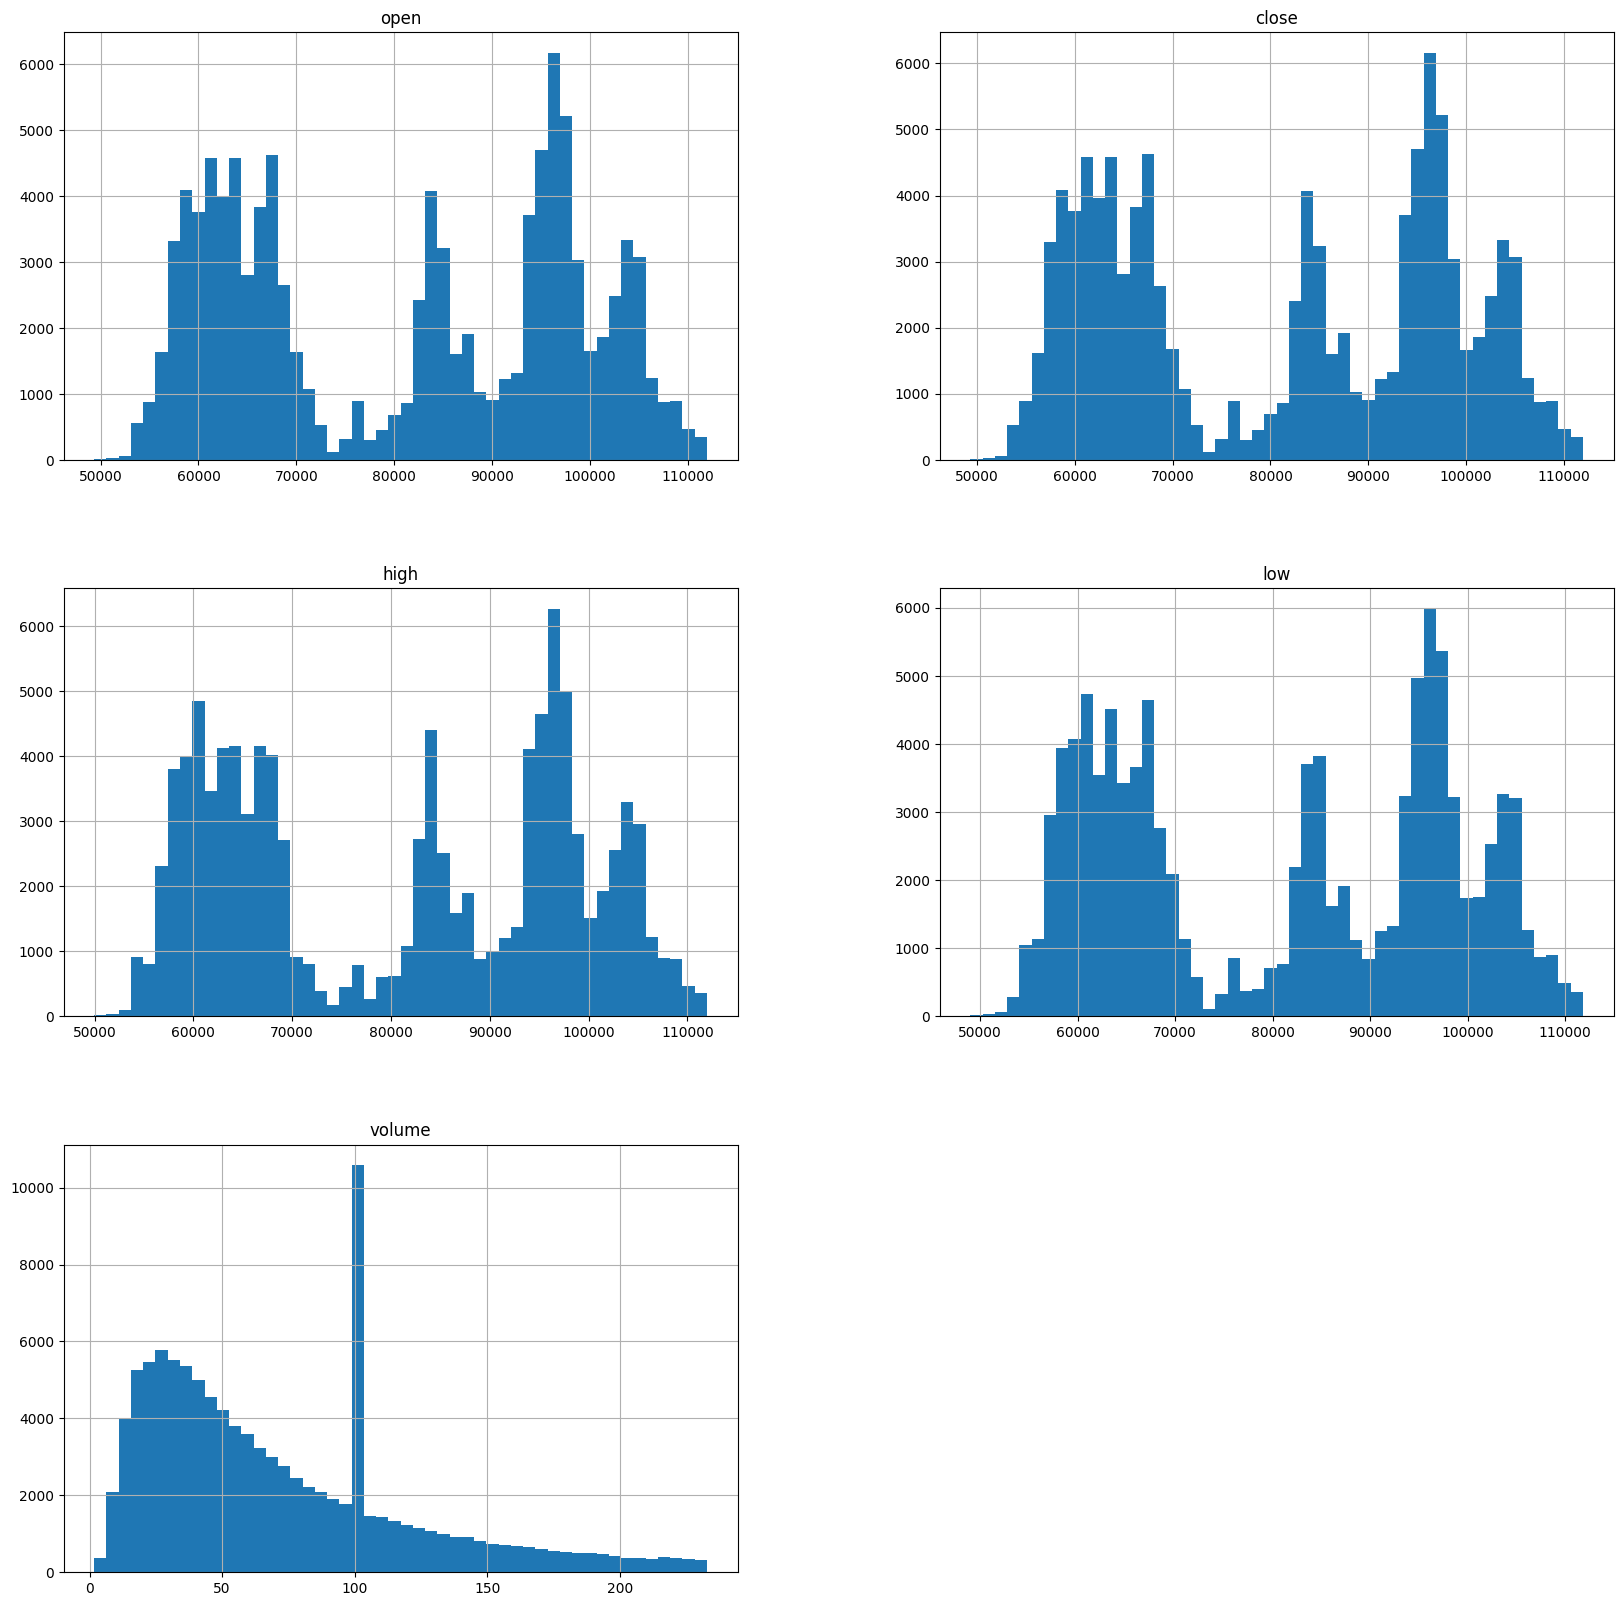

In [84]:
df[OCHLV].hist(figsize=(20, 20), bins=50)
plt.show()

#### Momentum

In [90]:
df[MOMENTUM].describe()

,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,PVO,PVO_HIST,PVO_SIGNAL,ROC,RSI,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL,TSI
count,105088.000000,105112.000000,105096.000000,105088.000000,105088.000000,105096.000000,105088.000000,105088.000000,105109.000000,105108.000000,105095.000000,105108.000000,105106.000000,105084.000000
mean,5.001187,81038.971722,0.002549,-0.000002,0.002548,-1.380031,0.000208,-1.380230,0.006278,50.372917,0.501705,51.209112,51.208671,0.755759
std,363.407385,16943.646188,0.176040,0.052628,0.165923,12.388403,6.300397,10.191330,0.540032,10.967584,0.357425,29.794942,27.556611,18.449217
min,-3567.873088,50687.935750,-1.916957,-0.622071,-1.608772,-52.191992,-19.501072,-48.355710,-7.348482,8.474526,0.000000,0.000000,0.000000,-70.563083
25%,-138.607816,64113.946546,-0.068516,-0.023339,-0.064762,-9.865759,-4.169148,-8.266559,-0.219125,43.062292,0.165030,25.187606,26.296337,-11.804512
50%,9.213662,83834.174504,0.005139,-0.000412,0.005039,-1.806766,-0.728895,-1.365293,0.006706,50.555679,0.503365,51.769631,51.693610,1.008945
75%,155.085919,96577.352006,0.078722,0.023329,0.074713,6.374860,3.291495,5.211023,0.235566,57.745228,0.839484,77.503950,76.274256,13.363364
max,4895.497941,111640.246496,1.823188,0.678299,1.701378,59.275106,50.151545,38.656686,7.057981,93.901451,1.000000,100.000000,100.000000,74.403186


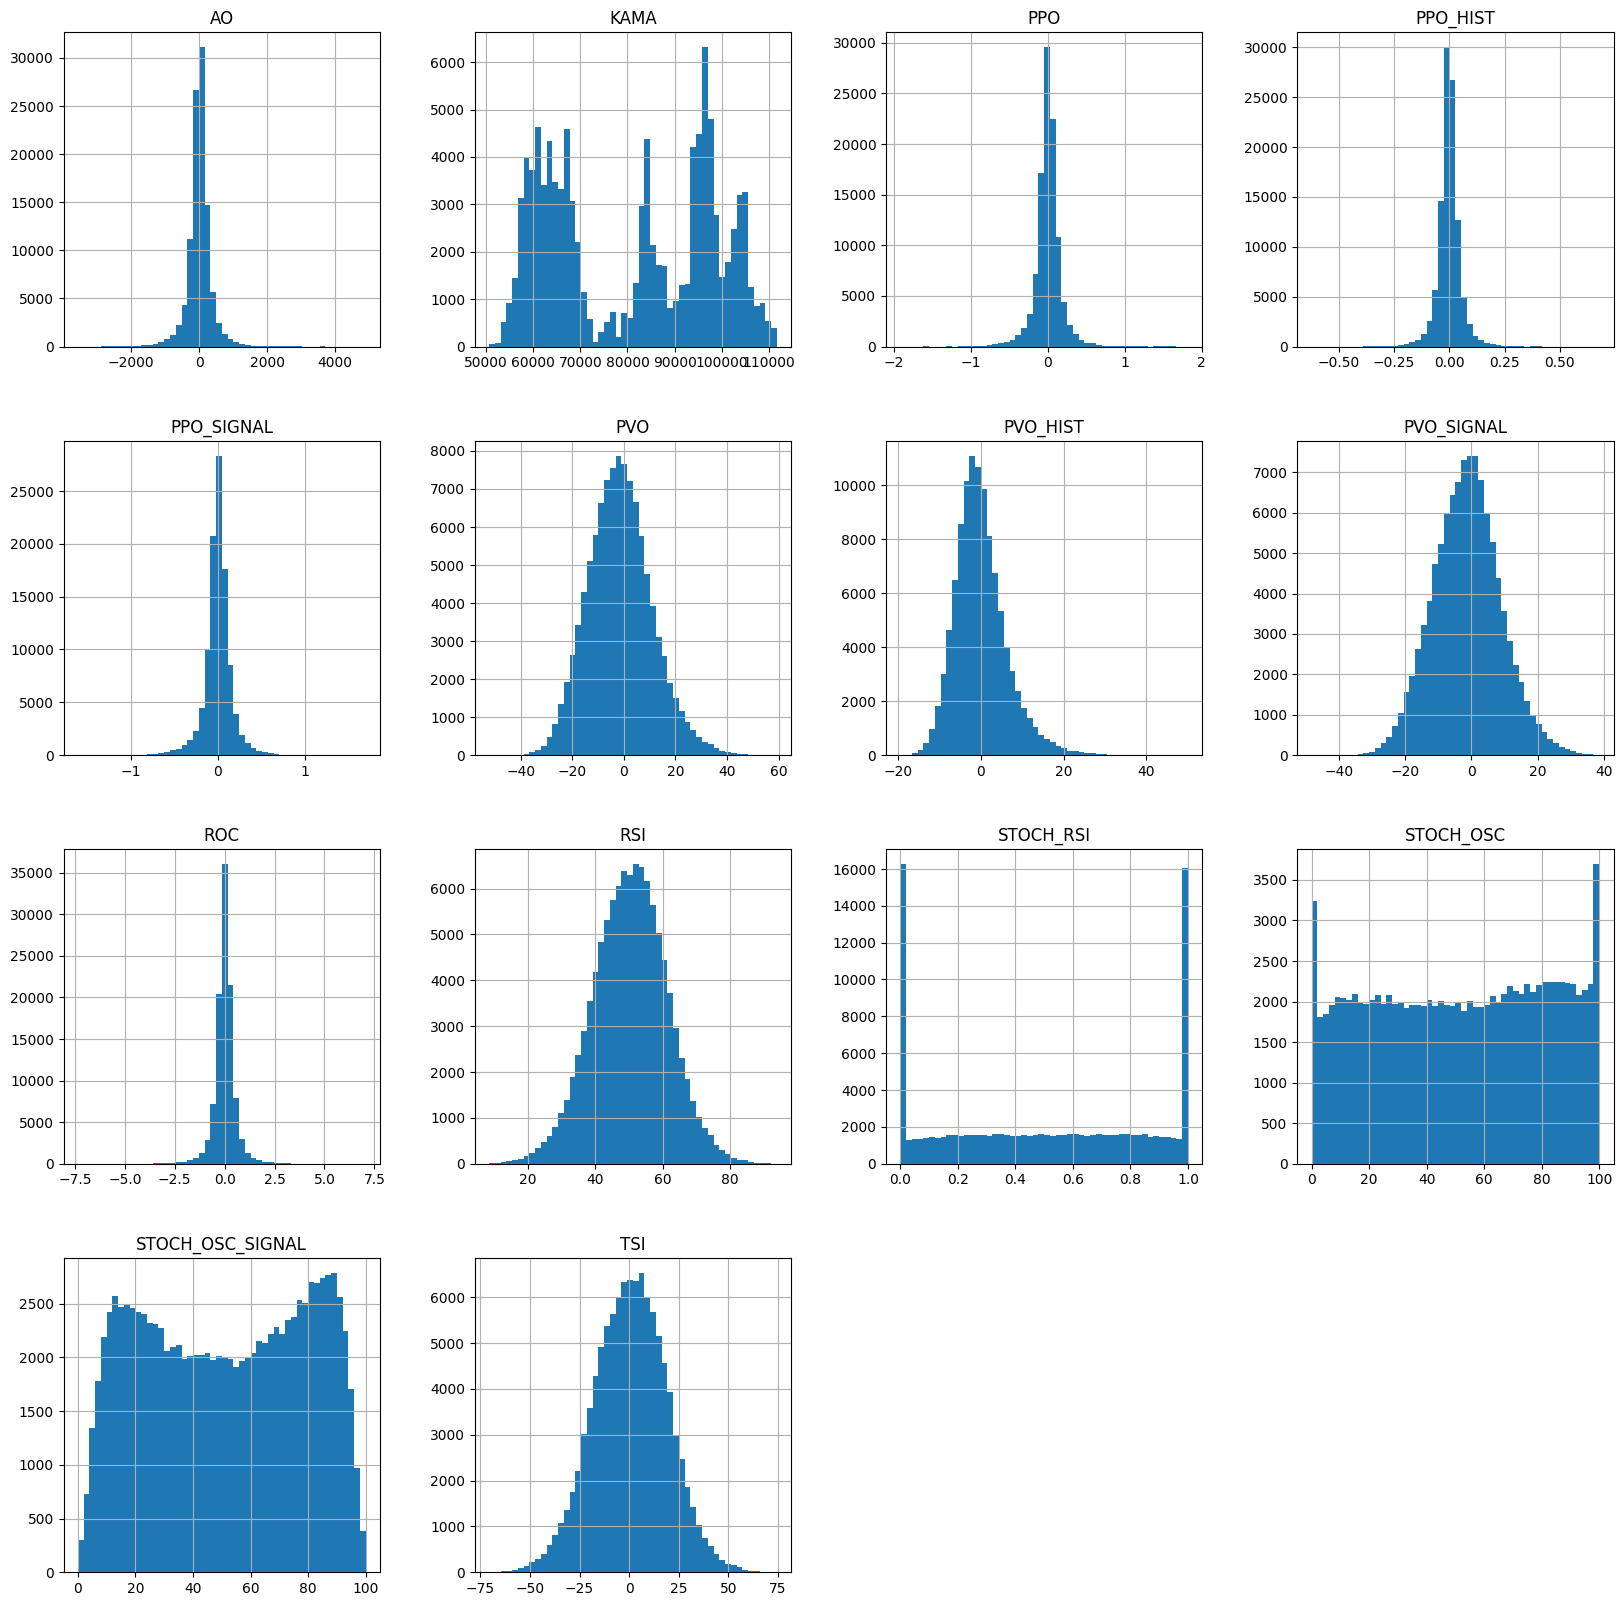

In [85]:
df[MOMENTUM].hist(figsize=(20, 20), bins=50)
plt.show()

#### Volumen

In [91]:
df[VOLUME].describe()

,ADI,CMF,EoM,EMV,FI,MFI,NVI,OBV,VPT,VWAP
count,105121.000000,105102.000000,1.051200e+05,1.051070e+05,105108.000000,105108.000000,105121.000000,105121.000000,105120.000000,105108.000000
mean,50669.827141,0.010655,-5.067689e+08,-5.088548e+08,4.518801,50.027012,1241.408159,18856.626328,-1.015171,81040.896325
std,33515.690070,0.157824,1.203977e+11,3.351540e+10,4058.044592,16.766610,140.405362,14456.509309,21.979336,16941.308515
min,-98.854047,-0.666187,-2.944065e+13,-2.123786e+12,-68632.970723,0.000000,987.552755,-9396.900087,-52.265374,50221.362381
25%,11442.010684,-0.096132,-8.390296e+09,-3.064116e+09,-1007.547412,37.924404,1121.700140,3636.680422,-18.776483,64097.592666
50%,66542.079030,0.011115,7.080605e+06,8.246694e+07,24.187022,50.038258,1250.279205,23603.262132,0.957295,83833.397410
75%,82788.788743,0.117789,8.559514e+09,3.186094e+09,1116.916113,62.245698,1355.485160,30836.284110,18.817509,96575.055953
max,93169.856249,0.718331,4.641347e+12,8.859790e+11,65336.812947,100.000000,1534.233375,43341.841557,37.908497,111739.423432


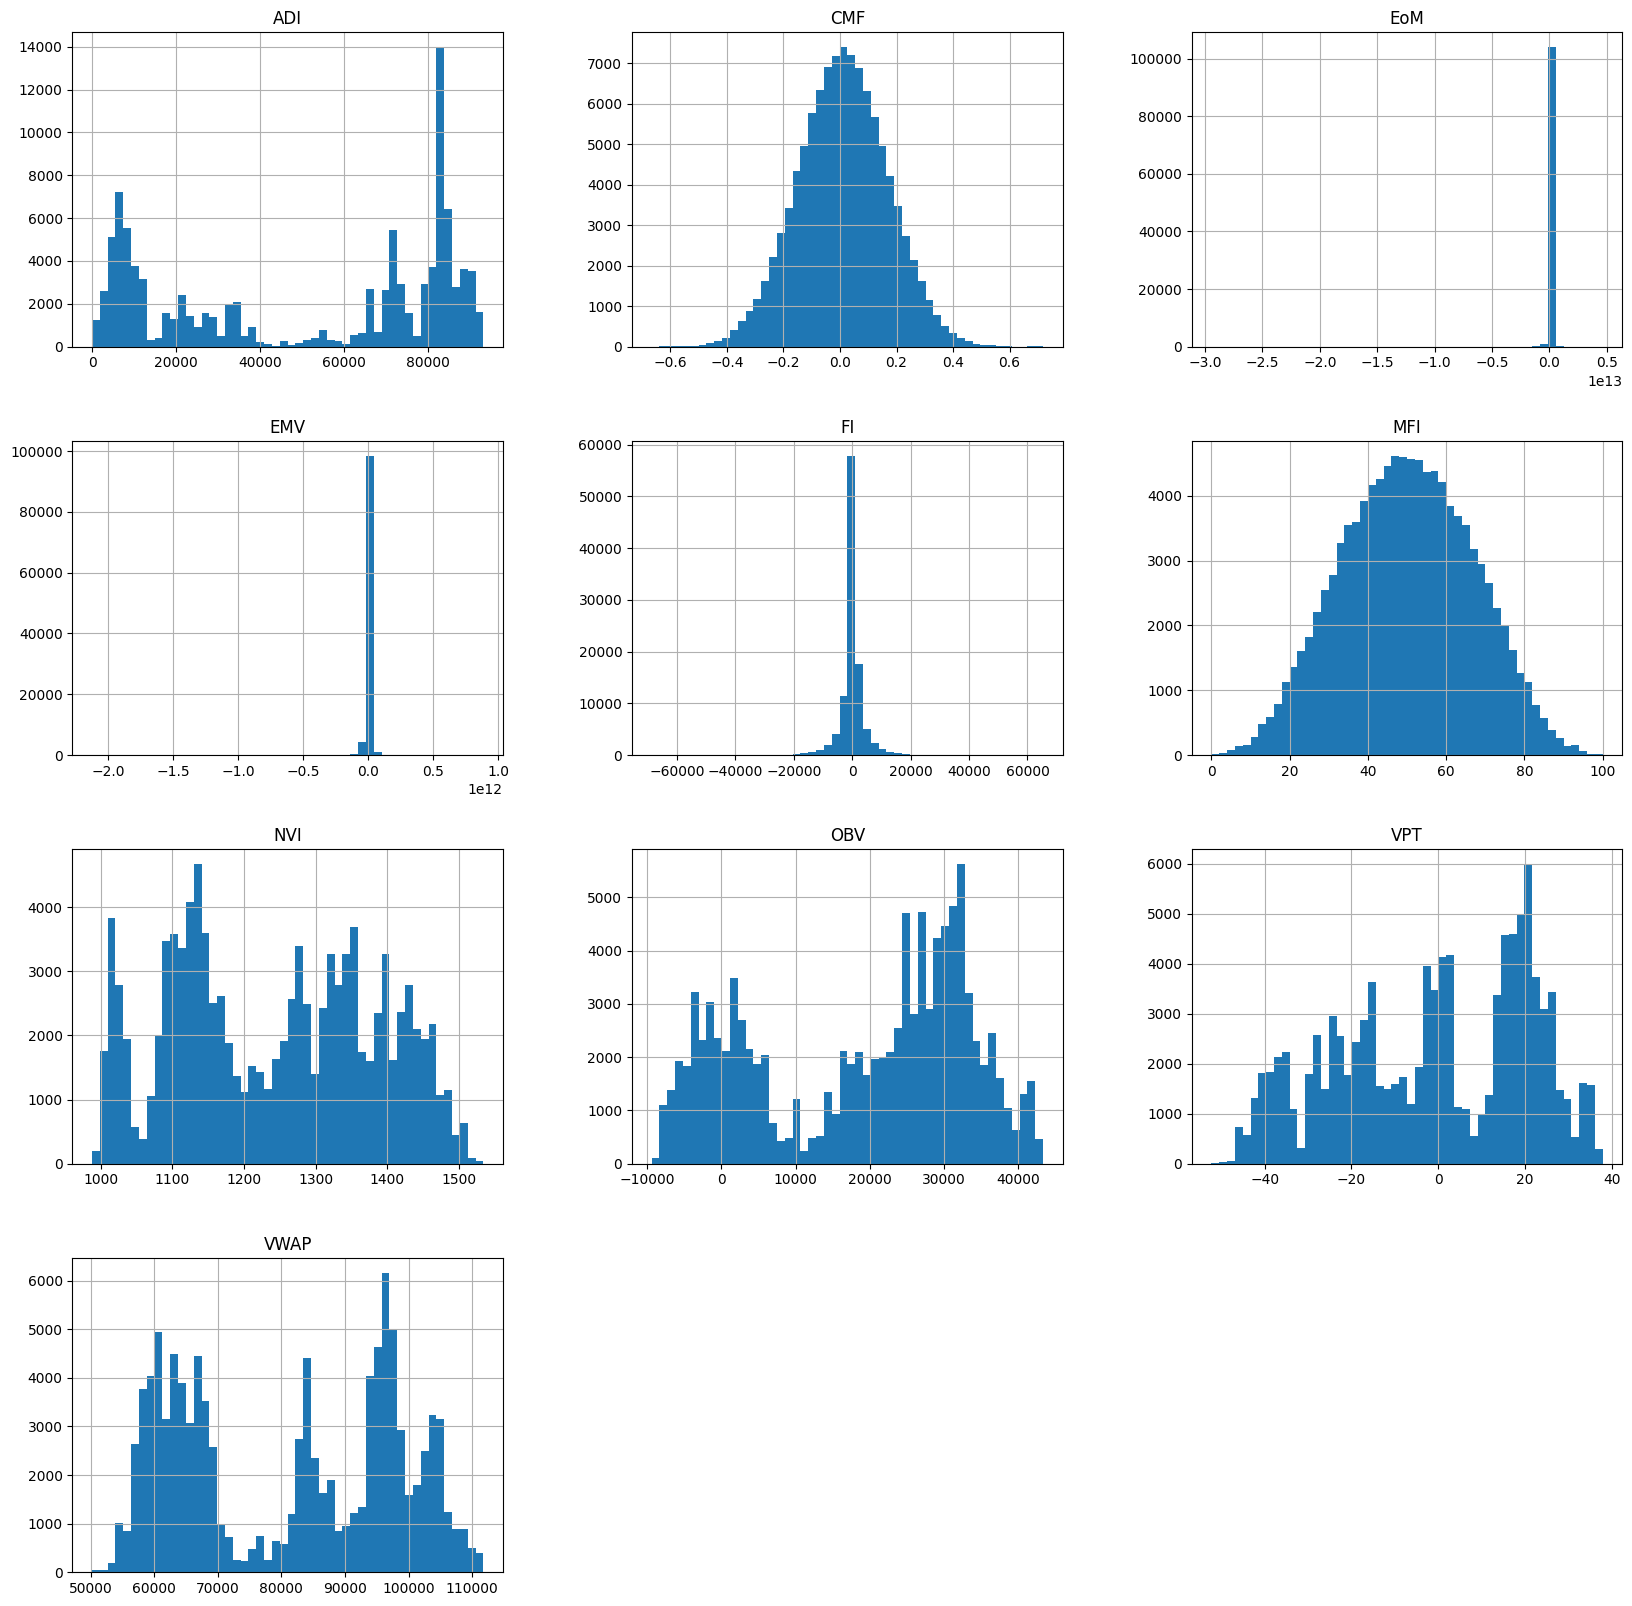

In [86]:
df[VOLUME].hist(figsize=(20, 20), bins=50)
plt.show()

#### Volatility

In [92]:
df[VOLATILITY].describe()

,ATR,BBANDS_HIGH,BBANDS_HIGH_INDI,BBANDS_LOWER,BBANDS_LOWER_INDI,BBANDS_MIDDLE,BBANDS_CHANNEL,BBANDS_WIDTH,DONCHIAN_HIGH,DONCHIAN_LOW,...,DONCHIAN_PERCENTAGE,DONCHIAN_WIDTH,KELTNER_HIGH,KELTNER_HIGH_INDI,KELTNER_LOW,KELTNER_LOW_INDI,KELTNER_MIDDLE,KELTNER_PERCENTAGE,KELTNER_WIDTH,ULCER_INDEX
count,105121.000000,105102.000000,105121.000000,105102.000000,105121.000000,105102.000000,105102.000000,105102.000000,105102.000000,105102.000000,...,105102.000000,105102.000000,105121.000000,105121.000000,105121.000000,105121.000000,105102.000000,105121.000000,105102.000000,105108.000000
mean,152.589676,81391.663756,0.056782,80691.522010,0.058751,81041.592883,0.506078,0.867077,81411.701331,80650.963128,...,0.514952,0.943938,81191.380140,0.278974,80886.184628,0.262659,81040.936457,0.520455,0.377941,0.346360
std,101.346770,17011.399629,0.231427,16876.460540,0.235160,16941.258165,0.328566,0.742457,17011.232463,16871.520186,...,0.292605,0.728761,16969.956809,0.448497,16910.973620,0.440081,16940.928442,0.858986,0.252432,0.337053
min,0.000000,51535.110799,0.000000,48686.167072,0.000000,50473.117500,-0.556350,0.050791,51640.490000,49000.000000,...,0.000000,0.058027,51042.720000,0.000000,49775.918000,0.000000,50480.640500,-4.195300,0.019757,0.004325
25%,85.562413,64311.559099,0.000000,63858.843631,0.000000,64096.797875,0.243902,0.429896,64318.820000,63816.050000,...,0.261549,0.499140,64172.956333,0.000000,64018.736833,0.000000,64096.157333,-0.032294,0.215817,0.144116
50%,127.386363,84171.833743,0.000000,83454.463666,0.000000,83839.931000,0.516592,0.652804,84203.690000,83409.090000,...,0.524765,0.741774,84000.538667,0.000000,83660.676500,0.000000,83837.753083,0.534535,0.312544,0.249094
75%,189.493744,96901.283604,0.000000,96256.485781,0.000000,96580.545500,0.766349,1.034538,96924.000000,96202.980000,...,0.769770,1.147985,96721.948500,1.000000,96429.564000,1.000000,96578.067000,1.071460,0.467562,0.424316
max,1476.575039,112284.305074,1.000000,111392.260452,1.000000,111682.710500,1.560557,10.833275,111980.000000,111379.220000,...,1.000000,10.857242,111872.738167,1.000000,111488.555167,1.000000,111680.646667,6.461352,3.335968,4.974310


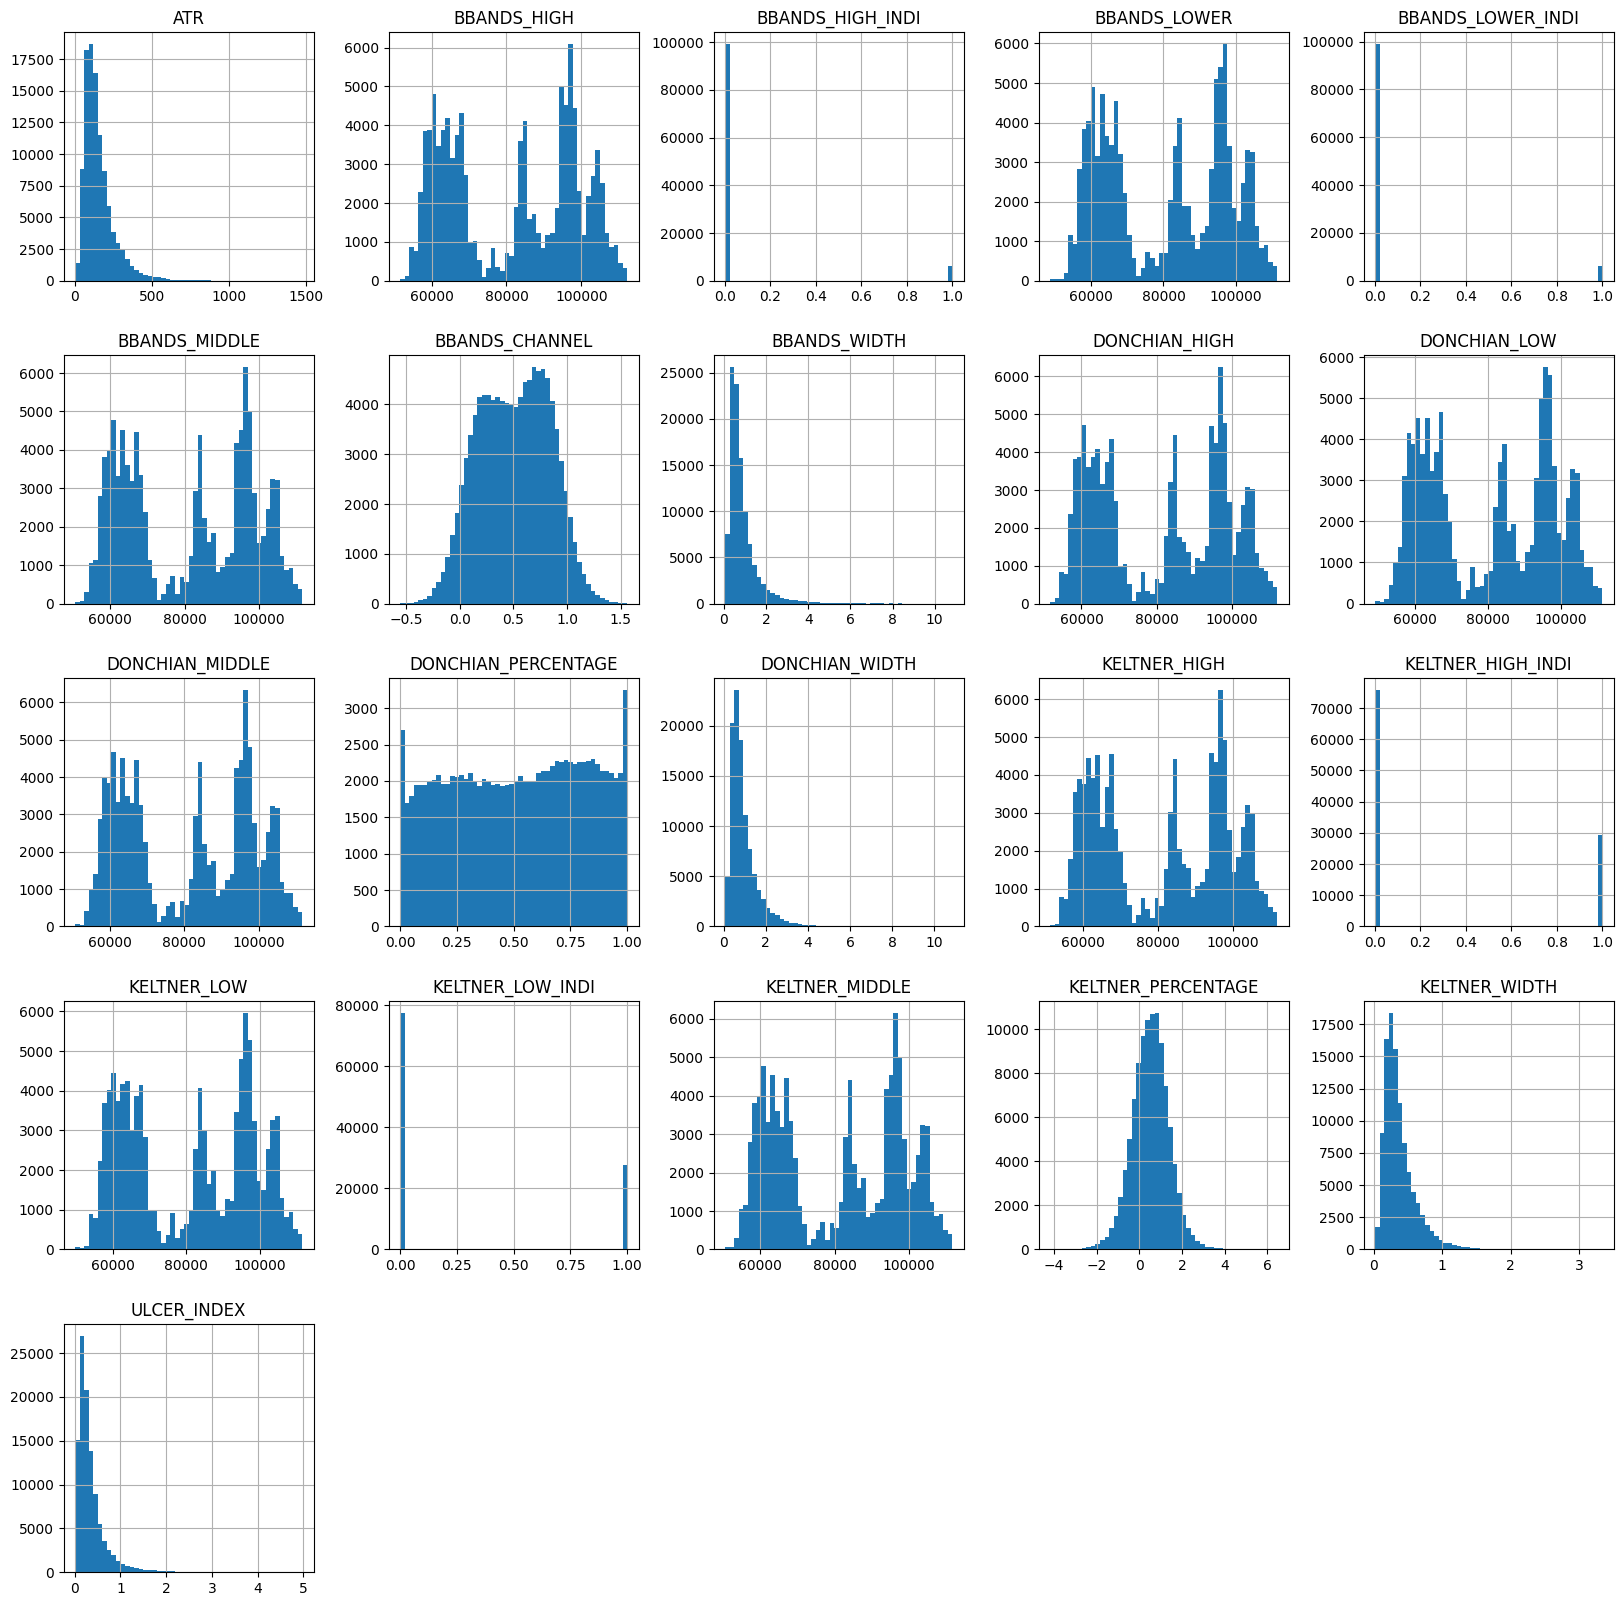

In [87]:
df[VOLATILITY].hist(figsize=(20, 20), bins=50)
plt.show()

#### Trend

In [93]:
df[TREND].describe()

,ADX,ADX_POS,ADX_NEG,AROON_UP,AROON_DOWN,AROON_INDI,CCI,DPO,EMA,KST,...,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA,VI_POS,VI_NEG,VI_DIFF,WMA
count,105121.000000,105121.000000,105121.000000,105096.000000,105096.000000,105096.000000,105102.000000,105102.000000,105108.000000,105107.000000,...,105107.000000,105096.000000,105088.000000,105088.000000,105081.000000,105108.000000,105107.000000,105107.000000,105107.000000,105108.000000
mean,24.403827,23.473481,23.497101,47.852858,46.330212,1.522646,2.076500,-0.516538,81041.949164,0.095948,...,0.005038,2.421796,2.421758,-0.001463,24.930304,81041.950075,1.005980,0.995616,0.010364,81042.698441
std,9.999282,8.067873,7.867436,35.556779,35.513854,61.519297,110.920228,172.992859,16941.327364,6.092009,...,1.897852,143.420778,135.128051,43.001901,1.632416,16941.866258,0.173498,0.170447,0.339283,16942.338962
min,0.000000,0.000000,0.000000,0.000000,0.000000,-100.000000,-558.885709,-3034.398000,50246.268523,-138.757549,...,-18.246464,-1204.342743,-956.947865,-495.832950,18.721716,50201.332857,0.231102,0.154251,-1.314552,50115.079429
25%,16.889455,17.812896,17.948614,12.000000,12.000000,-56.000000,-83.292614,-73.145500,64102.151770,-2.332382,...,-0.853029,-53.790064,-50.614691,-18.339583,23.811126,64100.246964,0.883872,0.877583,-0.232673,64101.084286
50%,22.300329,22.906634,22.895702,48.000000,44.000000,12.000000,5.839669,0.475250,83838.426276,0.170072,...,-0.015876,3.941998,3.910572,-0.269042,24.755696,83834.098929,1.010346,0.999988,0.010932,83831.836286
75%,29.899435,28.434328,28.315281,84.000000,80.000000,56.000000,86.330165,74.164875,96583.184427,2.674114,...,0.846209,62.114411,59.218778,18.498975,25.878773,96578.141964,1.129640,1.118191,0.250444,96579.183619
max,75.862033,78.562443,75.661542,100.000000,100.000000,100.000000,543.127093,2156.694500,111708.867629,64.420254,...,27.578006,1713.440432,1543.369576,632.062555,32.583755,111728.397143,1.964244,1.642198,1.479364,111730.558000


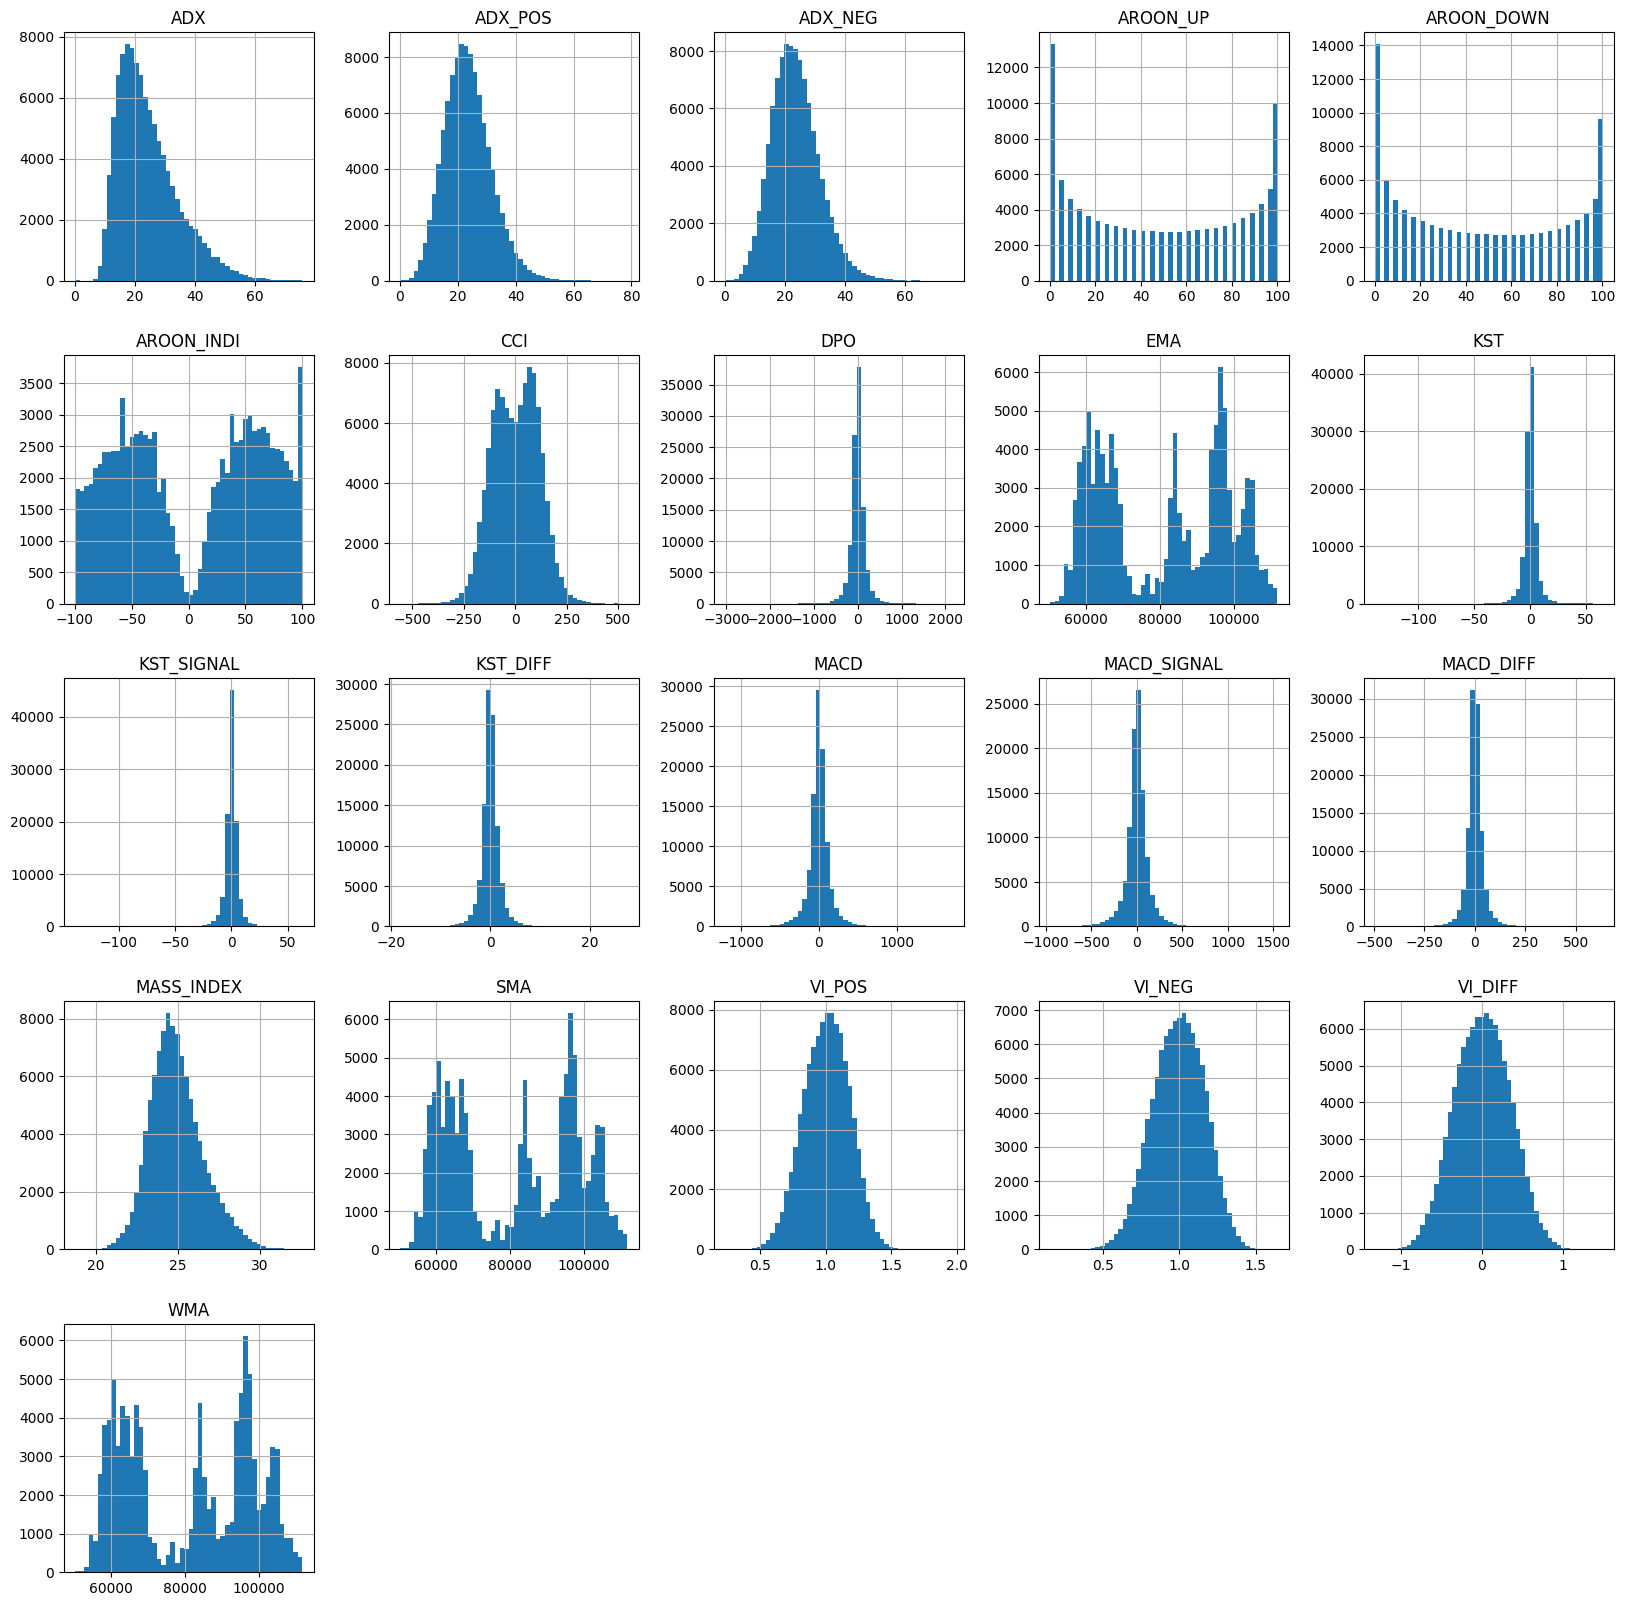

In [88]:
df[TREND].hist(figsize=(20, 20), bins=50)
plt.show()